# Sentiment Classification
## 1. Introduction


<div style="text-align: center;">
  <img src="pics/roadmap.png" alt="" width="100%">
</div>


This notebook investigates how sentiment classification performance changes when the amount and quality of manual labels are varied, and whether a semi-supervised weak-labeling pipeline can reduce the need for human annotation.

The task is a **three-class sentiment classification problem** with the labels **positive**, **neutral**, and **negative**. Because negative sentiment is often the most difficult and most important class in practice, the analysis focuses primarily on **negative F1** as the main comparison metric, while also reporting accuracy, macro-F1, precision, and recall.

The experiments are organized around three central questions from the assignment:

1. **How many manually labeled examples are needed?**  
   This is analyzed through nested hard-label training sets of size **100, 250, 500, and 1000**.

2. **How important is annotator agreement?**  
   The notebook separates high-agreement and lower-agreement data in two ways:
   - through two fixed evaluation sets, `test_allagree` and `test_disagree`
   - through a direct comparison of **high-agreement seeds** versus **lower-agreement seeds** in the weak-labeling pipeline

3. **Which semi-supervised configuration works best?**  
   The notebook compares:
   - **DistilBERT** and **ModernBERT** as supervised baselines
   - **SBERT** and plain **BERT mean pooling** as embedding models for k-NN weak labeling
   - **majority vote** and **distance-weighted vote** for weak-label generation
   - hard-label-only training versus **hard + weak-label** retraining

A deliberate design choice throughout this notebook is to keep the implementation **computationally manageable, fully traceable, and runnable from scratch**. For that reason, the experiments use a **small and transparent training setup**:  
The classifier models are trained for a fixed number of **3 epochs**, with a batch size of **16**, and the learning-rate tuning is limited to a **small targeted sweep** over only a few candidate values on one representative split. This is a pragmatic compromise rather than an attempt to maximize absolute benchmark performance. In the context of this challenge, the priority is to build a solution that is **methodologically understandable, complete in scope, and practically executable end-to-end**, rather than to run an extensive hyperparameter search that would dramatically increase runtime while adding relatively little insight into the underlying modeling choices. These simplifications are therefore intentional and aligned with the goal of producing a notebook that can be reviewed, reproduced, and discussed clearly.

In [41]:
import inspect
import os
from pathlib import Path
from typing import Dict, List

import torch

# Keep local caches inside the notebook folder so reruns stay submission-friendly.
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["MPLCONFIGDIR"] = os.path.abspath(".matplotlib")
os.environ["NUMBA_CACHE_DIR"] = os.path.abspath(".numba_cache")
os.makedirs(os.environ["MPLCONFIGDIR"], exist_ok=True)
os.makedirs(os.environ["NUMBA_CACHE_DIR"], exist_ok=True)

from IPython.display import Markdown, display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_style("whitegrid")
sns.set_context("notebook")

from datasets import Dataset, disable_progress_bars, load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import NearestNeighbors
from transformers import (
    AutoModel,
    AutoTokenizer,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    logging as transformers_logging,
    set_seed as hf_set_seed,
)

from models import (
    SentimentClassifier,
    compute_confusion_matrix,
    compute_metrics,
    get_device,
)

try:
    import umap

    UMAP_AVAILABLE = True
    UMAP_IMPORT_ERROR = None
except Exception as exc:
    umap = None
    UMAP_AVAILABLE = False
    UMAP_IMPORT_ERROR = exc

try:
    from openai import OpenAI

    OPENAI_CLIENT_AVAILABLE = True
    OPENAI_IMPORT_ERROR = None
except Exception as exc:
    OpenAI = None
    OPENAI_CLIENT_AVAILABLE = False
    OPENAI_IMPORT_ERROR = exc

transformers_logging.set_verbosity_error()
disable_progress_bars()


## 2. Dataset
### 2.1 Data Description

The experiments in this notebook are based on the **Financial PhraseBank**, a benchmark dataset of short financial news statements annotated for sentiment. Each sentence is assigned to one of three classes: **positive**, **neutral**, or **negative**. 

The dataset is challenging for several reasons:

- **Financial sentiment is subtle.** Many sentences are phrased in a factual and neutral style, even when they carry positive or negative implications for a company or market.
- **Class boundaries are not always obvious.** In particular, the distinction between neutral and mildly positive or negative statements can be ambiguous.
- **Annotator disagreement is meaningful.** Lower agreement often reflects genuinely borderline cases rather than simple labeling noise, which makes this a useful test bed for studying how robust a sentiment model is under ambiguity.
- **Negative examples are especially important.** From an application perspective, missing negative sentiment can be more costly than confusing positive and neutral statements, which is why this notebook places special emphasis on negative F1 in the evaluation.

In [2]:
def _find_local_phrasebank_dir() -> Path:
    """Locate a local Financial PhraseBank cache if HF loading is unavailable."""
    candidate_roots = [
        Path.cwd() / "FinancialPhraseBank-v1.0",
        Path.home() / ".cache" / "huggingface" / "datasets" / "downloads" / "extracted",
    ]

    for root in candidate_roots:
        if not root.exists():
            continue

        if (
            root.name == "FinancialPhraseBank-v1.0"
            and (root / "Sentences_AllAgree.txt").exists()
        ):
            return root

        for candidate in root.rglob("FinancialPhraseBank-v1.0"):
            if (candidate / "Sentences_AllAgree.txt").exists():
                return candidate

    raise FileNotFoundError(
        "Could not find a local FinancialPhraseBank-v1.0 directory. "
        "Download the dataset once with Hugging Face or place the raw files locally."
    )


def _load_phrasebank_subset(
    config_name: str,
    dataset_name: str = "takala/financial_phrasebank",
) -> pd.DataFrame:
    """Load one agreement subset with a local fallback."""
    label_map = {"negative": 0, "neutral": 1, "positive": 2}
    filename_map = {
        "sentences_allagree": "Sentences_AllAgree.txt",
        "sentences_75agree": "Sentences_75Agree.txt",
        "sentences_66agree": "Sentences_66Agree.txt",
        "sentences_50agree": "Sentences_50Agree.txt",
    }

    try:
        dataset_dir = _find_local_phrasebank_dir()
    except FileNotFoundError:
        dataset_dir = None

    if dataset_dir is not None:
        rows = []
        with open(
            dataset_dir / filename_map[config_name],
            encoding="iso-8859-1",
        ) as handle:
            for line in handle:
                sentence, label = line.rsplit("@", 1)
                rows.append(
                    {
                        "sentence": sentence,
                        "label": label_map[label.strip()],
                    }
                )
        df = pd.DataFrame(rows)
    else:
        dataset = load_dataset(dataset_name, config_name, split="train")
        df = dataset.to_pandas()[["sentence", "label"]].copy()
        if df["label"].dtype == object:
            df["label"] = df["label"].map(label_map)

    df["agreement_subset"] = config_name
    return df


def _deduplicate_sentences(df: pd.DataFrame, subset_name: str) -> pd.DataFrame:
    """Drop duplicate sentences and keep the first occurrence."""
    duplicate_rows = df[df.duplicated(subset=["sentence"], keep=False)]
    if not duplicate_rows.empty:
        conflicting_duplicates = (
            duplicate_rows.groupby("sentence")["label"].nunique().gt(1).sum()
        )
        deduped = df.drop_duplicates(subset=["sentence"], keep="first").copy()
        removed_rows = len(df) - len(deduped)
        print(
            f"{subset_name}: removed {removed_rows} duplicate rows "
            f"across {duplicate_rows['sentence'].nunique()} duplicated sentences "
            f"({conflicting_duplicates} conflicting-label cases resolved by "
            "first occurrence)."
        )
        return deduped.reset_index(drop=True)

    return df.reset_index(drop=True)


def _attach_example_ids(df: pd.DataFrame, prefix: str) -> pd.DataFrame:
    result = df.copy().reset_index(drop=True)
    result.index = [f"{prefix}_{idx:05d}" for idx in range(len(result))]
    result.index.name = "example_id"
    return result


def load_agreement_aware_splits(
    dataset_name: str = "takala/financial_phrasebank",
    seed: int = 42,
    test_size: float = 0.2,
    val_size: float = 0.1,
    train_sizes: List[int] = [100, 250, 500, 1000],
) -> Dict[str, pd.DataFrame]:
    """Create clean train/validation/test splits with agreement awareness."""
    if train_sizes != sorted(train_sizes):
        raise ValueError("train_sizes must be sorted in ascending order.")

    max_train_size = max(train_sizes)

    print("Loading Financial PhraseBank agreement subsets...")
    allagree_df = _deduplicate_sentences(
        _load_phrasebank_subset("sentences_allagree", dataset_name),
        subset_name="100% agreement subset",
    )
    allagree_df = _attach_example_ids(allagree_df, prefix="allagree")

    # Keep the lower-agreement pool separate from the clean 100% subset.
    non100_frames = []
    for config_name in ["sentences_75agree", "sentences_66agree", "sentences_50agree"]:
        subset_df = _load_phrasebank_subset(config_name, dataset_name)
        non100_frames.append(subset_df)

    combined_non100_df = pd.concat(non100_frames, ignore_index=True)
    combined_non100_df = combined_non100_df[
        ~combined_non100_df["sentence"].isin(set(allagree_df["sentence"]))
    ].copy()
    combined_non100_df = _deduplicate_sentences(
        combined_non100_df,
        subset_name="Combined non-100% agreement pool",
    )
    combined_non100_df = _attach_example_ids(combined_non100_df, prefix="disagree")

    # Freeze one very clean test set and one disagreement-aware test set.
    remaining_allagree_df, test_allagree_df = train_test_split(
        allagree_df,
        test_size=test_size,
        random_state=seed,
        stratify=allagree_df["label"],
    )
    remaining_disagree_df, test_disagree_df = train_test_split(
        combined_non100_df,
        test_size=test_size,
        random_state=seed,
        stratify=combined_non100_df["label"],
    )

    train_hidden_allagree_df, val_allagree_df = train_test_split(
        remaining_allagree_df,
        test_size=val_size,
        random_state=seed,
        stratify=remaining_allagree_df["label"],
    )

    if len(train_hidden_allagree_df) <= max_train_size:
        raise ValueError(
            "Not enough 100%-agreement data left after test/val splits to support "
            f"max training size {max_train_size}."
        )

    shuffled_clean_pool = train_hidden_allagree_df.sample(frac=1, random_state=seed)
    hard_label_train_pool = shuffled_clean_pool.iloc[:max_train_size].copy()

    # This hidden clean pool stays fixed so weak-label comparisons use the same target.
    hidden_allagree_pool = shuffled_clean_pool.iloc[max_train_size:].copy()

    if hidden_allagree_pool.empty:
        raise ValueError(
            "hidden_allagree_pool is empty; adjust split sizes or train_sizes."
        )

    splits = {
        "allagree_full": allagree_df,
        "combined_non100_pool": combined_non100_df,
        "remaining_disagree_pool": remaining_disagree_df.copy(),
        "test_allagree": test_allagree_df.copy(),
        "test_disagree": test_disagree_df.copy(),
        "val_allagree": val_allagree_df.copy(),
        "hard_label_train_pool": hard_label_train_pool.copy(),
        "hidden_allagree_pool": hidden_allagree_pool.copy(),
    }

    for size in train_sizes:
        if size > len(hard_label_train_pool):
            raise ValueError(
                "Requested train size "
                f"{size} exceeds available hard-label pool "
                f"{len(hard_label_train_pool)}."
            )
        # Later train sizes extend earlier ones, so the learning curves stay nested.
        splits[f"train_{size}"] = hard_label_train_pool.iloc[:size].copy()

    print()
    print("Agreement-aware split sizes:")
    for key in [
        "allagree_full",
        "combined_non100_pool",
        "test_allagree",
        "test_disagree",
        "val_allagree",
        "hard_label_train_pool",
        "hidden_allagree_pool",
    ]:
        print(f"  {key}: {len(splits[key])}")
    for size in train_sizes:
        print(f"  train_{size}: {len(splits[f'train_{size}'])}")

    return splits


### 2.2 Data Preparation

This notebook treats the dataset as an agreement-aware dataset rather than a single flat corpus. We load the four published agreement subsets separately and deduplicate repeated sentences.

For hard-label training we use only the deduplicated **100% agreement** subset. This keeps the seed training data as clean as possible before any weak-labeling step is introduced.

We also keep **two frozen test sets**:
- `test_allagree` measures performance on the cleanest labels.
- `test_disagree` measures robustness on sentences that required weaker annotator agreement.

The **hidden clean pool** also comes from originally labeled 100%-agreement data. Later weak-labeling experiments can therefore treat it as unlabeled during training while we still retain trustworthy ground truth for offline evaluation.

#### Load Agreement-Aware Data and Create Frozen Splits

We use the `load_agreement_aware_splits` helper defined above.

Method summary:
- Load `sentences_allagree`, `sentences_75agree`, `sentences_66agree`, and `sentences_50agree` separately.
- Use only deduplicated 100%-agreement data for `train_*`, `val_allagree`, and `hidden_allagree_pool`.
- Build a combined non-100%-agreement pool from the remaining subsets, removing duplicates while keeping higher-agreement rows first.
- Freeze `test_allagree` and `test_disagree` once and reuse them for every later experiment.
- Keep `hidden_allagree_pool` constant for every train size so comparisons stay methodologically aligned.

In [3]:
# Set up the frozen splits and the shared experiment constants once.
splits = load_agreement_aware_splits()
train_sizes = [100, 250, 500, 1000]

test_allagree_df = splits["test_allagree"]
test_disagree_df = splits["test_disagree"]
val_allagree_df = splits["val_allagree"]
hidden_allagree_pool = splits["hidden_allagree_pool"]

SENTIMENT_ID2LABEL = {
    0: "negative",
    1: "neutral",
    2: "positive",
}
SENTIMENT_LABEL2ID = {
    label_name: label_id for label_id, label_name in SENTIMENT_ID2LABEL.items()
}
NEGATIVE_LABEL = 0

BASELINE_MODEL_NAMES = {
    "distilbert": "distilbert-base-uncased",
    "modernbert": "answerdotai/ModernBERT-base",
}
BASELINE_COMPARISON_TRAIN_SIZE = max(train_sizes)
SHOW_PROGRESS_BARS = False


def prepare_text_dataset(df, tokenizer, text_column="sentence", label_column="label"):
    keep_columns = [text_column]
    if label_column in df.columns:
        keep_columns.append(label_column)

    dataset = Dataset.from_pandas(
        df[keep_columns].reset_index(drop=True),
        preserve_index=False,
    )

    def tokenize_batch(batch):
        return tokenizer(batch[text_column], truncation=True)

    return dataset.map(
        tokenize_batch,
        batched=True,
        remove_columns=[text_column],
        desc=None,
    )


def create_training_args(
    output_dir,
    batch_size=16,
    epochs=3,
    learning_rate=2e-5,
    seed=42,
):
    device = get_device()
    hf_set_seed(seed)

    training_kwargs = {
        "output_dir": output_dir,
        "eval_strategy": "no",
        "save_strategy": "no",
        "learning_rate": learning_rate,
        "per_device_train_batch_size": batch_size,
        "per_device_eval_batch_size": batch_size,
        "num_train_epochs": epochs,
        "weight_decay": 0.01,
        "load_best_model_at_end": False,
        "logging_strategy": "no",
        "disable_tqdm": True,
        "report_to": "none",
        "seed": seed,
        "data_seed": seed,
        "dataloader_num_workers": 0,
        "dataloader_pin_memory": device.type == "cuda",
    }

    signature = inspect.signature(TrainingArguments.__init__)
    if "use_mps_device" in signature.parameters:
        training_kwargs["use_mps_device"] = device.type == "mps"
    if "use_cpu" in signature.parameters:
        training_kwargs["use_cpu"] = device.type == "cpu"
    elif "no_cuda" in signature.parameters:
        training_kwargs["no_cuda"] = device.type == "cpu"

    return TrainingArguments(**training_kwargs)


print("Available split keys:")
for key in splits:
    print(f"  {key}")

print()
print("Baseline backbones to compare:")
for key, model_name in BASELINE_MODEL_NAMES.items():
    print(f"  {key}: {model_name}")
print()
print(f"Learning-curve train sizes: {train_sizes}")
print("Frozen evaluation splits: val_allagree, test_allagree, test_disagree")
print(f"Hidden clean pool size: {len(hidden_allagree_pool)}")


Loading Financial PhraseBank agreement subsets...
100% agreement subset: removed 5 duplicate rows across 5 duplicated sentences (0 conflicting-label cases resolved by first occurrence).
Combined non-100% agreement pool: removed 3145 duplicate rows across 1952 duplicated sentences (2 conflicting-label cases resolved by first occurrence).

Agreement-aware split sizes:
  allagree_full: 2259
  combined_non100_pool: 2579
  test_allagree: 452
  test_disagree: 516
  val_allagree: 181
  hard_label_train_pool: 1000
  hidden_allagree_pool: 626
  train_100: 100
  train_250: 250
  train_500: 500
  train_1000: 1000
Available split keys:
  allagree_full
  combined_non100_pool
  remaining_disagree_pool
  test_allagree
  test_disagree
  val_allagree
  hard_label_train_pool
  hidden_allagree_pool
  train_100
  train_250
  train_500
  train_1000

Baseline backbones to compare:
  distilbert: distilbert-base-uncased
  modernbert: answerdotai/ModernBERT-base

Learning-curve train sizes: [100, 250, 500, 100

#### Result Discussion

The loading step shows that the agreement-aware setup is workable and well structured. After deduplication, the notebook retains **2259 examples** in the 100%-agreement subset and **2579 examples** in the combined non-100%-agreement pool. The large number of removed duplicates mainly reflects overlap between the original PhraseBank agreement subsets, while the very small number of conflicting-label cases suggests that the cleaning step is methodologically unproblematic.

The resulting split design is a strong basis for the later experiments. The clean data is divided into a validation set, nested hard-label training subsets of size **100, 250, 500, and 1000**, and a fixed hidden clean pool of **626 examples**. 

### 2.3 Sanity Check

Verify the nested hard-label training property, enforce split separation, and inspect class distributions for both frozen test sets.

In [4]:
train_100 = splits["train_100"]
train_250 = splits["train_250"]
train_500 = splits["train_500"]
train_1000 = splits["train_1000"]

# The seed sets should be nested so later learning-curve points extend earlier ones.
assert set(train_100.index).issubset(set(train_250.index))
assert set(train_250.index).issubset(set(train_500.index))
assert set(train_500.index).issubset(set(train_1000.index))


def assert_no_sentence_overlap(
    name_a: str,
    df_a: pd.DataFrame,
    name_b: str,
    df_b: pd.DataFrame,
) -> None:
    overlap = set(df_a["sentence"]) & set(df_b["sentence"])
    assert not overlap, (
        f"Overlap detected between {name_a} and {name_b}: "
        f"{len(overlap)} shared sentences"
    )


held_out_groups = [
    ("val_allagree", splits["val_allagree"]),
    ("test_allagree", splits["test_allagree"]),
    ("test_disagree", splits["test_disagree"]),
    ("hidden_allagree_pool", splits["hidden_allagree_pool"]),
]

for train_name in ["train_100", "train_250", "train_500", "train_1000"]:
    for held_out_name, held_out_df in held_out_groups:
        assert_no_sentence_overlap(
            train_name,
            splits[train_name],
            held_out_name,
            held_out_df,
        )

for idx, (name_a, df_a) in enumerate(held_out_groups):
    for name_b, df_b in held_out_groups[idx + 1 :]:
        assert_no_sentence_overlap(name_a, df_a, name_b, df_b)

label_names = {0: "negative", 1: "neutral", 2: "positive"}


def label_distribution(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    counts = df["label"].value_counts().sort_index().rename(index=label_names)
    proportions = (
        df["label"]
        .value_counts(normalize=True)
        .sort_index()
        .rename(index=label_names)
    )
    return pd.DataFrame(
        {
            f"{split_name}_count": counts,
            f"{split_name}_share": proportions.round(3),
        }
    )


distribution_summary = pd.concat(
    [
        label_distribution(splits["test_allagree"], "test_allagree"),
        label_distribution(splits["test_disagree"], "test_disagree"),
    ],
    axis=1,
).fillna(0)

print("Hierarchical property verified.")
print("No overlap detected between train / val / test / hidden splits.")
display(distribution_summary)


Hierarchical property verified.
No overlap detected between train / val / test / hidden splits.


,test_allagree_count,test_allagree_share,test_disagree_count,test_disagree_share
label,,,,
negative,61,0.135,60,0.116
neutral,277,0.613,297,0.576
positive,114,0.252,159,0.308


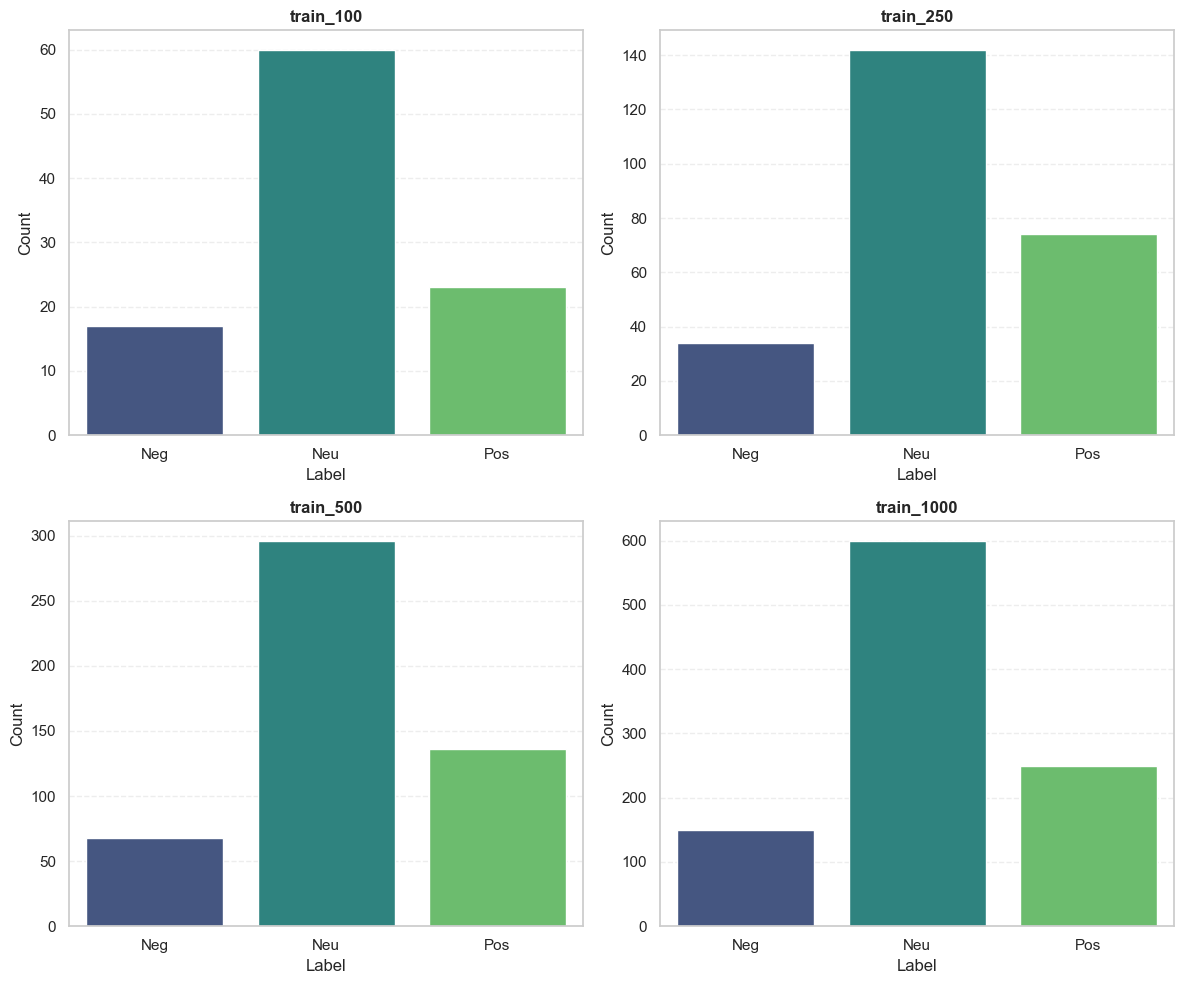

In [42]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

palette = sns.color_palette("viridis", 3)

for i, size in enumerate(train_sizes):
    train_df = splits[f"train_{size}"].copy()
    train_df["label"] = train_df["label"].astype(int)

    sns.countplot(
        data=train_df,
        x="label",
        hue="label",
        order=[0, 1, 2],
        hue_order=[0, 1, 2],
        palette=palette,
        legend=False,
        ax=axes[i]
    )

    axes[i].set_title(f"train_{size}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Label")
    axes[i].set_ylabel("Count")
    axes[i].set_xticks([0, 1, 2])
    axes[i].set_xticklabels(["Neg", "Neu", "Pos"])
    axes[i].grid(axis="y", linestyle="--", alpha=0.35)

plt.tight_layout()
plt.show()

#### Result Discussion

The sanity checks confirm that the split construction is correct and consistent. The nested training subsets satisfy the intended hierarchical property, and there is no overlap between training, validation, test, and hidden-pool data. This is important because it prevents information leakage and makes the later comparisons between hard-label and semi-supervised setups methodologically valid.

The class distributions of the two test sets are broadly similar, with **neutral** as the dominant class in both cases. At the same time, `test_disagree` contains a slightly smaller share of **negative** examples and a slightly larger share of **positive** examples than `test_allagree`. These differences are not large, but they should be kept in mind when interpreting later performance gaps between the two test sets.

The bar plots for `train_100`, `train_250`, `train_500`, and `train_1000` show that the same class imbalance is also present in the training data. Because the nested splits preserve this overall structure, the training setup remains consistent across sizes. At the same time, the relatively small number of negative examples helps explain why **negative F1** is a particularly important metric in the later analysis and why weak-labeling gains in the low-label regime are especially relevant for this class.

## 3. Baseline
### 3.1 Baseline Models

As supervised baselines, this notebook compares **DistilBERT** and **ModernBERT**. Both are transformer-based language models, but they differ in their design goals and expected strengths.

* **DistilBERT** is a compact and efficient version of BERT. It was created through knowledge distillation, meaning that it aims to retain much of BERT’s language understanding while using fewer parameters and requiring less computation. In practice, this makes DistilBERT a strong baseline when training time and hardware constraints matter. For this notebook, it is especially useful as a reference model because it is lightweight, widely used, and easy to fine-tune.

* **ModernBERT**, by contrast, represents a newer transformer design. It is intended to be a stronger and more modern encoder baseline, with improved architecture and training choices compared with older BERT-family models. In this notebook, ModernBERT serves as the more powerful comparison model: if it outperforms DistilBERT, that would suggest that the later semi-supervised experiments should build on the stronger backbone rather than on the simpler one.


### 3.2 Baseline Comparison

The baseline comparison is designed as a controlled supervised experiment in which both transformer backbones are trained under the same conditions and then evaluated on the same fixed splits.

For this first comparison, both models are trained on the largest clean hard-label split, **`train_1000`**, which contains only examples from the **100% agreement subset**. This choice gives each model enough data to learn a meaningful sentiment classifier while keeping the setup aligned with the idea of using the most reliable human labels for the initial supervised baseline.

After training, each model is evaluated on three fixed datasets:

- **`val_allagree`**: used as the development set for model selection and light hyperparameter choices
- **`test_allagree`**: the main clean benchmark, containing only 100%-agreement examples
- **`test_disagree`**: the harder robustness benchmark, containing examples from lower-agreement subsets

This separation is important. The validation set is used to support development decisions without contaminating the test sets, while the two test sets make it possible to compare performance on **clean labels** versus **more ambiguous labels**.

The reported metrics include **accuracy**, **macro-F1**, **negative precision**, **negative recall**, and **negative F1**. Among these, **negative F1** is the main decision metric, because the negative class is both the smallest and one of the most important classes in practice. A model that performs well overall but fails to identify negative sentiment reliably would be less useful for the purposes of this task.

In [6]:
baseline_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

baseline_results = []
baseline_train_sizes = train_sizes

# This loop builds the hard-label baseline learning curves for both backbones.
for baseline_model_key, baseline_model_name in BASELINE_MODEL_NAMES.items():
    print()
    print(
        f"=== Baseline learning curve: {baseline_model_key} "
        f"({baseline_model_name}) ==="
    )

    for baseline_train_size in baseline_train_sizes:
        print(f"Training {baseline_model_key} on train_{baseline_train_size}")
        baseline_train_df = splits[f"train_{baseline_train_size}"]

        baseline_classifier = SentimentClassifier(
            model_name=baseline_model_name,
            num_labels=len(SENTIMENT_ID2LABEL),
        )
        baseline_classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

        train_dataset = prepare_text_dataset(
            baseline_train_df,
            baseline_classifier.tokenizer,
        )
        val_dataset = prepare_text_dataset(
            val_allagree_df,
            baseline_classifier.tokenizer,
        )
        data_collator = DataCollatorWithPadding(tokenizer=baseline_classifier.tokenizer)

        baseline_trainer = Trainer(
            model=baseline_classifier.model,
            args=create_training_args(
                output_dir=f"models/{baseline_model_key}_{baseline_train_size}",
                batch_size=16,
                epochs=3,
                seed=42,
            ),
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=data_collator,
            compute_metrics=lambda eval_pred: compute_metrics(
                eval_pred,
                negative_label=NEGATIVE_LABEL,
            ),
        )

        baseline_trainer.train()

        for evaluation_split_name, evaluation_split_df in baseline_eval_splits.items():
            evaluation_dataset = prepare_text_dataset(
                evaluation_split_df,
                baseline_classifier.tokenizer,
            )
            evaluation_predictions = baseline_trainer.predict(evaluation_dataset)
            evaluation_metrics = compute_metrics(
                (
                    evaluation_predictions.predictions,
                    evaluation_predictions.label_ids,
                ),
                negative_label=NEGATIVE_LABEL,
            )

            baseline_results.append(
                {
                    "model_key": baseline_model_key,
                    "model_name": baseline_model_name,
                    "train_size": baseline_train_size,
                    "evaluation_split": evaluation_split_name,
                    **evaluation_metrics,
                }
            )

print(f"Collected {len(baseline_results)} baseline evaluation rows.")



=== Baseline learning curve: distilbert (distilbert-base-uncased) ===
Training distilbert on train_100


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'train_runtime': '1.977', 'train_samples_per_second': '151.8', 'train_steps_per_second': '10.62', 'train_loss': '1.015', 'epoch': '3'}
Training distilbert on train_250


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

{'train_runtime': '3.835', 'train_samples_per_second': '195.6', 'train_steps_per_second': '12.52', 'train_loss': '0.8488', 'epoch': '3'}
Training distilbert on train_500


...

{'train_runtime': '9.032', 'train_samples_per_second': '83.04', 'train_steps_per_second': '5.314', 'train_loss': '0.6021', 'epoch': '3'}
Training modernbert on train_500


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '18.27', 'train_samples_per_second': '82.12', 'train_steps_per_second': '5.256', 'train_loss': '0.4909', 'epoch': '3'}
Training modernbert on train_1000


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '36.71', 'train_samples_per_second': '81.72', 'train_steps_per_second': '5.148', 'train_loss': '0.2834', 'epoch': '3'}
Collected 24 baseline evaluation rows.


#### Baseline Comparison Table and Plot

In [7]:
baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df = baseline_results_df[
    [
        "model_key",
        "model_name",
        "train_size",
        "evaluation_split",
        "negative_f1",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
    ]
].sort_values(
    ["evaluation_split", "model_key", "train_size"],
    ascending=[True, True, True],
).reset_index(drop=True)

display(
    baseline_results_df.style.format(
        {
            "negative_f1": "{:.4f}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"], cmap="YlGn")
)

,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,distilbert,distilbert-base-uncased,100,test_allagree,0.0000,0.6128,0.2533,0.0000,0.0000
1,distilbert,distilbert-base-uncased,250,test_allagree,0.0000,0.7389,0.4920,0.0000,0.0000
2,distilbert,distilbert-base-uncased,500,test_allagree,0.0000,0.7942,0.5359,0.0000,0.0000
3,distilbert,distilbert-base-uncased,1000,test_allagree,0.8730,0.9292,0.9000,0.8462,0.9016
4,modernbert,answerdotai/ModernBERT-base,100,test_allagree,0.1644,0.7389,0.5441,0.5000,0.0984
5,modernbert,answerdotai/ModernBERT-base,250,test_allagree,0.4038,0.7389,0.6144,0.4884,0.3443
6,modernbert,answerdotai/ModernBERT-base,500,test_allagree,0.4000,0.8186,0.6755,0.7083,0.2787
7,modernbert,answerdotai/ModernBERT-base,1000,test_allagree,0.9280,0.9513,0.9380,0.9062,0.9508
8,distilbert,distilbert-base-uncased,100,test_disagree,0.0000,0.5756,0.2435,0.0000,0.0000
9,distilbert,distilbert-base-uncased,250,test_disagree,0.0000,0.5640,0.2793,0.0000,0.0000


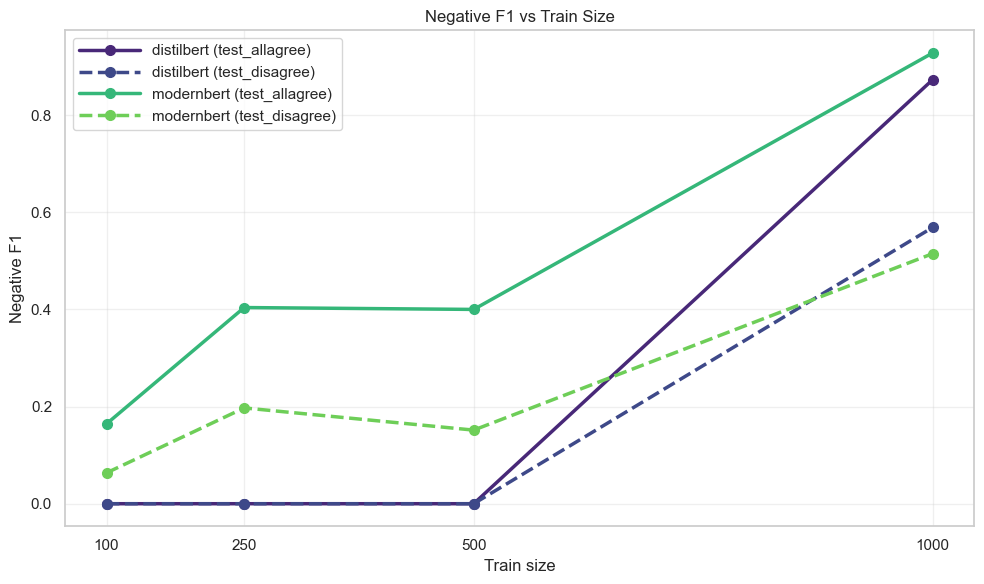

In [59]:
plot_df = baseline_results_df[
    baseline_results_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()

viridis_8 = sns.color_palette("viridis", 8)

# 1st, 2nd, 7th, 8th from the FIRST COLUMN / palette order
line_colors = {
    ("distilbert", "test_allagree"): viridis_8[0],
    ("distilbert", "test_disagree"): viridis_8[1],
    ("modernbert", "test_allagree"): viridis_8[5],
    ("modernbert", "test_disagree"): viridis_8[6],
}

split_styles = {
    "test_allagree": "-",
    "test_disagree": "--"
}

plt.figure(figsize=(10, 6))

for baseline_model_key in BASELINE_MODEL_NAMES:
    for split_name in ["test_allagree", "test_disagree"]:
        model_results_df = plot_df[
            (plot_df["model_key"] == baseline_model_key) &
            (plot_df["evaluation_split"] == split_name)
        ].sort_values("train_size")

        plt.plot(
            model_results_df["train_size"],
            model_results_df["negative_f1"],
            marker="o",
            linestyle=split_styles[split_name],
            color=line_colors[(baseline_model_key, split_name)],
            linewidth=2.5,
            markersize=7,
            label=f"{baseline_model_key} ({split_name})"
        )

plt.title("Negative F1 vs Train Size")
plt.xlabel("Train size")
plt.ylabel("Negative F1")
plt.xticks(baseline_train_sizes)
plt.grid(True, alpha=0.3)
plt.legend(loc="upper left", frameon=True, handlelength=4)
plt.tight_layout()
plt.show()

#### Result Discussion

The baseline comparison shows a clear difference between the two transformer backbones. **ModernBERT** performs more reliably than **DistilBERT** across almost the entire low-label regime, especially on the target metric **negative F1**. At training sizes **100, 250, and 500**, DistilBERT completely fails to identify the negative class on all three evaluation splits, resulting in a negative F1 of **0.00**. ModernBERT, in contrast, already detects at least part of the negative class at these smaller training sizes and therefore provides a much more useful baseline for the later semi-supervised experiments.

This difference is also visible in the learning-curve plot. ModernBERT improves earlier and more smoothly, whereas DistilBERT only “breaks through” at **train_1000**. On `test_allagree`, ModernBERT reaches negative F1 values of about **0.16**, **0.40**, **0.40**, and **0.93** as the train size increases, while DistilBERT remains at **0.00** until it jumps to about **0.87** at **1000** labels. This suggests that ModernBERT makes better use of limited clean supervision, which is especially important in this challenge because the low-label regime is a central part of the analysis.

The same general pattern appears on `val_allagree`, where ModernBERT is consistently stronger and reaches a very high negative F1 of **0.96** at **train_1000**, compared with **0.89** for DistilBERT. This supports the later decision to carry **ModernBERT** forward as the main classifier backbone in the weak-labeling and semi-supervised sections.

Performance on `test_disagree` is substantially lower for both models, which is expected because this split contains more ambiguous and lower-agreement examples. Still, ModernBERT remains more competitive at smaller train sizes, while DistilBERT again stays at **0.00** until the largest training split. At **train_1000**, the picture becomes more mixed: DistilBERT slightly exceeds ModernBERT on `test_disagree` negative F1 (**0.57** vs. **0.51**), even though ModernBERT remains stronger on the clean validation and clean test splits. This suggests that ModernBERT is the better overall choice, but also that robustness on ambiguous cases does not always improve in exactly the same way as performance on clean labels.

Overall, the baseline results justify selecting **ModernBERT** as the downstream backbone. It is clearly stronger in the low-label setting, which is the most relevant regime for studying weak labeling and annotation savings, and it achieves the best overall performance on the clean benchmark split.

# Weak Labeling

With the supervised baseline established, the next question is whether a small clean seed set can generate useful additional labels. This section first compares embedding spaces, then uses the stronger embedding setup for simple k-NN weak labeling.

## Embedding Models and Scope

For the weak-labeling step we compare:
- `sentence-transformers/all-MiniLM-L6-v2` as the SBERT-style sentence embedding model
- `bert-base-uncased` as a plain BERT baseline with simple mean pooling over token embeddings

We compare SBERT and plain BERT because the weak-label step depends on local neighborhood quality: if sentences with the same sentiment land closer together, k-NN labeling has a better chance to work.

The next cells keep the comparison lightweight but broaden it in two useful ways:
- a UMAP view of the `train_1000` seed embeddings as a visual sanity check
- a k-NN comparison that includes both `majority_vote` and `distance_weighted` voting

The agreement-level effect of lower-agreement seeds is then tested later in its own full train-size sweep.


In [9]:
SBERT_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"
BERT_MODEL_NAME = "bert-base-uncased"
EMBEDDING_BATCH_SIZE = 32

print("SBERT model:", SBERT_MODEL_NAME)
print("Plain BERT model:", BERT_MODEL_NAME)
print("Embedding batch size:", EMBEDDING_BATCH_SIZE)


SBERT model: sentence-transformers/all-MiniLM-L6-v2
Plain BERT model: bert-base-uncased
Embedding batch size: 32


## Load Embedding Models

The loading code stays explicit so the embedding choices and pooling rule remain visible in the notebook.

In [10]:
embedding_device = get_device()

sbert_model = SentenceTransformer(
    SBERT_MODEL_NAME,
    device=str(embedding_device),
)

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME, use_fast=True)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.to(embedding_device)
bert_model.eval()


def encode_with_plain_bert(sentences, batch_size=EMBEDDING_BATCH_SIZE):
    """Plain BERT baseline: mean-pool token embeddings with the attention mask."""
    pooled_batches = []

    for start in range(0, len(sentences), batch_size):
        batch_sentences = sentences[start : start + batch_size]
        batch = bert_tokenizer(
            batch_sentences,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        batch = {
            name: tensor.to(embedding_device)
            for name, tensor in batch.items()
        }

        with torch.no_grad():
            outputs = bert_model(**batch)

        # Mean pooling keeps the plain BERT baseline comparable to the sentence model.
        token_embeddings = outputs.last_hidden_state
        attention_mask = batch["attention_mask"].unsqueeze(-1)
        summed_embeddings = (token_embeddings * attention_mask).sum(dim=1)
        token_counts = attention_mask.sum(dim=1).clamp(min=1)
        pooled_embeddings = summed_embeddings / token_counts
        pooled_batches.append(pooled_embeddings.cpu().numpy())

    return np.vstack(pooled_batches)


print("Embedding device:", embedding_device)


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding device: mps


## Build Embeddings for the Seed Set and Hidden Pool

We embed the full clean hard-label pool once so later cells can slice the nested seed sets directly from the same embedding arrays.

In [11]:
# Build both embedding corpora once so later cells can reuse the same arrays.
embedding_train_df = splits["hard_label_train_pool"].copy()
embedding_hidden_df = splits["hidden_allagree_pool"].copy()

embedding_train_texts = embedding_train_df["sentence"].tolist()
embedding_train_labels = embedding_train_df["label"].to_numpy()
embedding_hidden_texts = embedding_hidden_df["sentence"].tolist()
embedding_hidden_labels = embedding_hidden_df["label"].to_numpy()

embedding_counts_df = pd.DataFrame(
    [
        {
            "split": "hard_label_train_pool",
            "rows": len(embedding_train_df),
            "label_source": "observed hard labels",
        },
        {
            "split": "hidden_allagree_pool",
            "rows": len(embedding_hidden_df),
            "label_source": "hidden clean labels for later offline checks",
        },
    ]
)

display(embedding_counts_df)


,split,rows,label_source
0,hard_label_train_pool,1000,observed hard labels
1,hidden_allagree_pool,626,hidden clean labels for later offline checks


In [12]:
sbert_train_embeddings = sbert_model.encode(
    embedding_train_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BARS,
)

sbert_hidden_embeddings = sbert_model.encode(
    embedding_hidden_texts,
    batch_size=EMBEDDING_BATCH_SIZE,
    show_progress_bar=SHOW_PROGRESS_BARS,
)

print("sbert_train_embeddings shape:", sbert_train_embeddings.shape)
print("sbert_hidden_embeddings shape:", sbert_hidden_embeddings.shape)


sbert_train_embeddings shape: (1000, 384)
sbert_hidden_embeddings shape: (626, 384)


In [13]:
bert_train_embeddings = encode_with_plain_bert(embedding_train_texts)
bert_hidden_embeddings = encode_with_plain_bert(embedding_hidden_texts)

print("bert_train_embeddings shape:", bert_train_embeddings.shape)
print("bert_hidden_embeddings shape:", bert_hidden_embeddings.shape)


bert_train_embeddings shape: (1000, 768)
bert_hidden_embeddings shape: (626, 768)


In [14]:
embedding_shapes_df = pd.DataFrame(
    [
        {
            "model": "SBERT",
            "model_name": SBERT_MODEL_NAME,
            "train_shape": tuple(sbert_train_embeddings.shape),
            "hidden_shape": tuple(sbert_hidden_embeddings.shape),
        },
        {
            "model": "BERT mean pool",
            "model_name": BERT_MODEL_NAME,
            "train_shape": tuple(bert_train_embeddings.shape),
            "hidden_shape": tuple(bert_hidden_embeddings.shape),
        },
    ]
)

display(embedding_shapes_df)

# Slice all nested seed sets from the same full clean embedding pool.
train_embedding_positions_by_size = {
    size: embedding_train_df.index.get_indexer(splits[f"train_{size}"].index)
    for size in train_sizes
}

sbert_train_embeddings_by_size = {
    size: sbert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
bert_train_embeddings_by_size = {
    size: bert_train_embeddings[positions]
    for size, positions in train_embedding_positions_by_size.items()
}
train_texts_by_size = {
    size: splits[f"train_{size}"]["sentence"].tolist()
    for size in train_sizes
}
train_labels_by_size = {
    size: splits[f"train_{size}"]["label"].to_numpy()
    for size in train_sizes
}

embedding_artifacts = {
    "train_df": embedding_train_df,
    "hidden_df": embedding_hidden_df,
    "train_texts": embedding_train_texts,
    "train_labels": embedding_train_labels,
    "hidden_texts": embedding_hidden_texts,
    "hidden_labels": embedding_hidden_labels,
    "train_positions_by_size": train_embedding_positions_by_size,
    "train_texts_by_size": train_texts_by_size,
    "train_labels_by_size": train_labels_by_size,
    "sbert": {
        "model_name": SBERT_MODEL_NAME,
        "train_embeddings": sbert_train_embeddings,
        "hidden_embeddings": sbert_hidden_embeddings,
        "train_embeddings_by_size": sbert_train_embeddings_by_size,
    },
    "bert": {
        "model_name": BERT_MODEL_NAME,
        "train_embeddings": bert_train_embeddings,
        "hidden_embeddings": bert_hidden_embeddings,
        "train_embeddings_by_size": bert_train_embeddings_by_size,
    },
}


,model,model_name,train_shape,hidden_shape
0,SBERT,sentence-transformers/all-MiniLM-L6-v2,"(1000, 384)","(626, 384)"
1,BERT mean pool,bert-base-uncased,"(1000, 768)","(626, 768)"


## Simple Embedding Diagnostics

Before building k-NN weak labels, we compare the two embedding spaces on the hard-labeled seed pool with simple cosine-based checks:
- mean intra-class cosine similarity
- mean inter-class cosine similarity
- leave-one-out 1-nearest-neighbor label purity
- class-centroid cosine similarity

If SBERT gives cleaner local neighborhoods and a larger same-label versus different-label gap, that is a good sign for the later k-NN weak-labeling step.


,model,mean_intra_class_cosine,mean_inter_class_cosine,similarity_gap,leave_one_out_1nn_purity
0,SBERT,0.159,0.158,0.001,0.775
1,BERT mean pool,0.641,0.654,-0.013,0.778



SBERT centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.615,0.862
neutral,0.615,1.000,0.759
positive,0.862,0.759,1.000



BERT mean pool centroid cosine similarity


,negative,neutral,positive
negative,1.000,0.928,0.991
neutral,0.928,1.000,0.947
positive,0.991,0.947,1.000


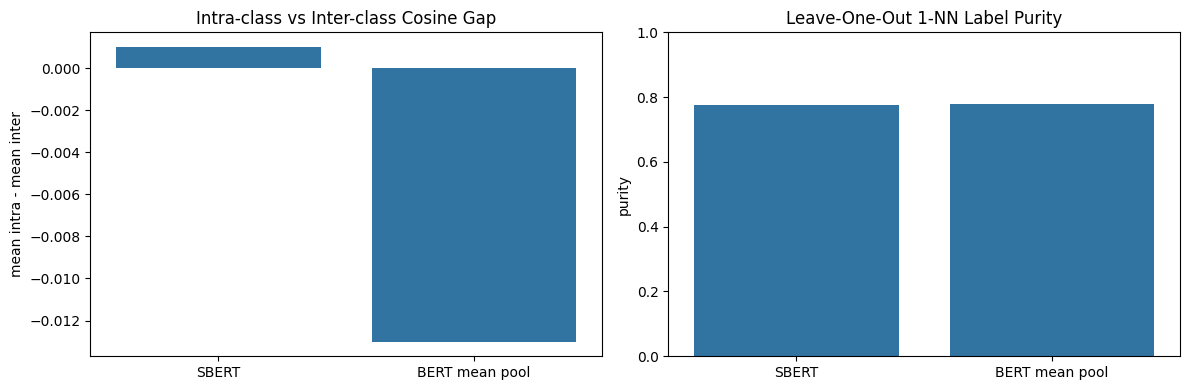

In [15]:
embedding_sets = {
    "SBERT": sbert_train_embeddings,
    "BERT mean pool": bert_train_embeddings,
}

similarity_rows = []
nn_rows = []
centroid_similarity_tables = {}

# These cheap diagnostics check whether the neighborhood structure looks useful for k-NN.
for model_label, embeddings in embedding_sets.items():
    normalized_embeddings = embeddings / np.clip(
        np.linalg.norm(embeddings, axis=1, keepdims=True),
        a_min=1e-12,
        a_max=None,
    )

    cosine_matrix = normalized_embeddings @ normalized_embeddings.T
    same_label_mask = (
        embedding_train_labels[:, None] == embedding_train_labels[None, :]
    )
    diagonal_mask = np.eye(len(embedding_train_labels), dtype=bool)

    intra_class_values = cosine_matrix[same_label_mask & ~diagonal_mask]
    inter_class_values = cosine_matrix[~same_label_mask]

    similarity_rows.append(
        {
            "model": model_label,
            "mean_intra_class_cosine": intra_class_values.mean(),
            "mean_inter_class_cosine": inter_class_values.mean(),
            "similarity_gap": intra_class_values.mean() - inter_class_values.mean(),
        }
    )

    leave_one_out_matrix = cosine_matrix.copy()
    np.fill_diagonal(leave_one_out_matrix, -np.inf)
    nearest_neighbor_indices = leave_one_out_matrix.argmax(axis=1)
    nearest_neighbor_labels = embedding_train_labels[nearest_neighbor_indices]
    nn_rows.append(
        {
            "model": model_label,
            "leave_one_out_1nn_purity": (
                nearest_neighbor_labels == embedding_train_labels
            ).mean(),
        }
    )

    centroid_vectors = {}
    centroid_order = [
        SENTIMENT_ID2LABEL[label_id]
        for label_id in sorted(SENTIMENT_ID2LABEL)
    ]
    for label_id, label_name in SENTIMENT_ID2LABEL.items():
        class_embeddings = normalized_embeddings[embedding_train_labels == label_id]
        centroid = class_embeddings.mean(axis=0)
        centroid = centroid / np.clip(np.linalg.norm(centroid), a_min=1e-12, a_max=None)
        centroid_vectors[label_name] = centroid

    centroid_table = pd.DataFrame(
        index=centroid_order,
        columns=centroid_order,
        dtype=float,
    )
    for row_label in centroid_order:
        for col_label in centroid_order:
            centroid_table.loc[row_label, col_label] = float(
                centroid_vectors[row_label] @ centroid_vectors[col_label]
            )
    centroid_similarity_tables[model_label] = centroid_table.round(3)

embedding_similarity_df = pd.DataFrame(similarity_rows).round(3)
embedding_nn_purity_df = pd.DataFrame(nn_rows).round(3)
embedding_quality_df = embedding_similarity_df.merge(
    embedding_nn_purity_df,
    on="model",
)

display(embedding_quality_df)

for model_label, centroid_table in centroid_similarity_tables.items():
    print()
    print(f"{model_label} centroid cosine similarity")
    display(centroid_table)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="similarity_gap",
    ax=axes[0],
)
axes[0].set_title("Intra-class vs Inter-class Cosine Gap")
axes[0].set_ylabel("mean intra - mean inter")
axes[0].set_xlabel("")

sns.barplot(
    data=embedding_quality_df,
    x="model",
    y="leave_one_out_1nn_purity",
    ax=axes[1],
)
axes[1].set_title("Leave-One-Out 1-NN Label Purity")
axes[1].set_ylabel("purity")
axes[1].set_xlabel("")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()


## UMAP Visualization of Seed Embeddings

As a lightweight bonus check, the next cell projects the `train_1000` seed embeddings into two dimensions. The goal is not to replace the quantitative diagnostics above, but to add a visual comparison between SBERT and plain BERT before the k-NN weak-labeling step.


/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/Users/stefanbinkert/Documents/FHNW_DS/NPR/NPR_MC_2/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


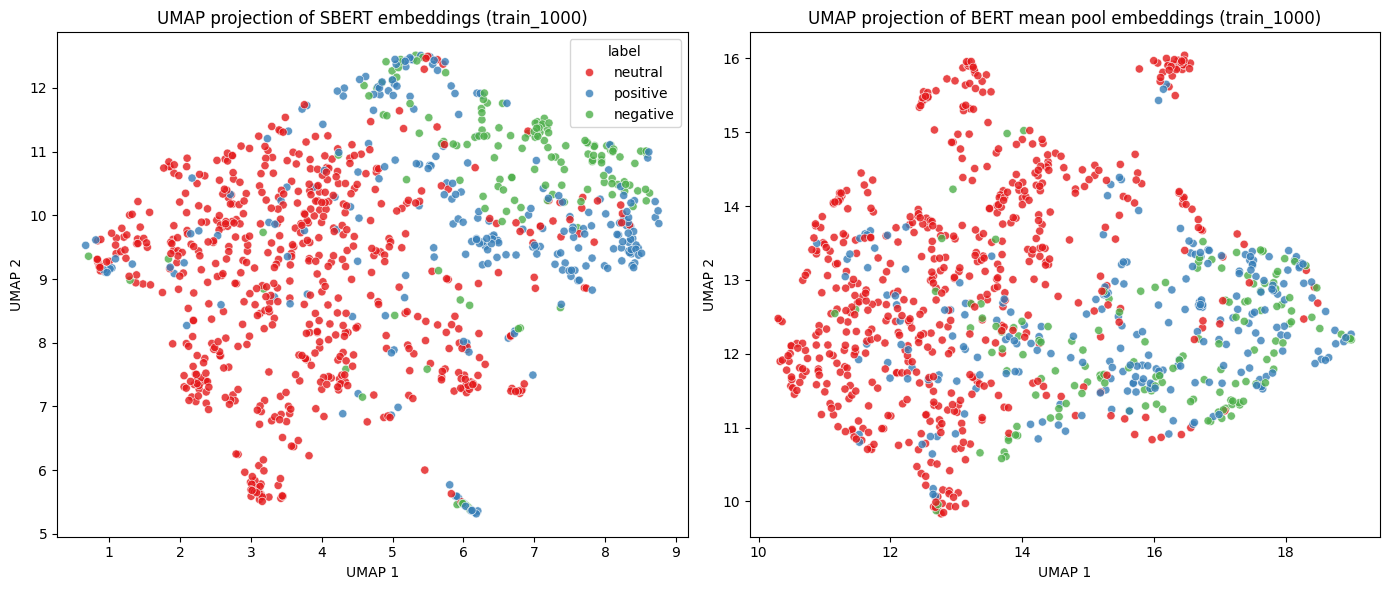

,model,mean_intra_class_distance_2d,mean_inter_class_distance_2d,distance_gap_2d,projected_1nn_purity
0,SBERT,2.723,3.754,1.031,0.745
1,BERT mean pool,2.822,3.659,0.838,0.675


In [16]:
umap_seed_size = max(train_sizes)
umap_seed_labels = train_labels_by_size[umap_seed_size]
umap_seed_label_names = pd.Series(umap_seed_labels).map(SENTIMENT_ID2LABEL).to_numpy()
umap_projection_by_model = {}
umap_projection_rows = []
umap_projection_quality_rows = []

if not UMAP_AVAILABLE:
    print(f"UMAP is unavailable in this environment: {UMAP_IMPORT_ERROR}")
    umap_projection_df = pd.DataFrame()
    umap_projection_quality_df = pd.DataFrame()
else:
    umap_embedding_sets = {
        "SBERT": sbert_train_embeddings_by_size[umap_seed_size],
        "BERT mean pool": bert_train_embeddings_by_size[umap_seed_size],
    }

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    for ax, (model_label, embeddings) in zip(axes, umap_embedding_sets.items()):
        reducer = umap.UMAP(
            n_components=2,
            n_neighbors=15,
            min_dist=0.1,
            random_state=42,
        )
        projection = reducer.fit_transform(embeddings)
        umap_projection_by_model[model_label] = projection

        projection_df = pd.DataFrame(
            {
                "umap_1": projection[:, 0],
                "umap_2": projection[:, 1],
                "label_id": umap_seed_labels,
                "label_name": umap_seed_label_names,
                "model": model_label,
            }
        )
        umap_projection_rows.append(projection_df)

        # This is only a visual sanity check, so we keep the summary metrics simple.
        distance_matrix = np.sqrt(
            ((projection[:, None, :] - projection[None, :, :]) ** 2).sum(axis=-1)
        )
        same_label_mask = umap_seed_labels[:, None] == umap_seed_labels[None, :]
        diagonal_mask = np.eye(len(umap_seed_labels), dtype=bool)
        intra_class_distance = distance_matrix[same_label_mask & ~diagonal_mask].mean()
        inter_class_distance = distance_matrix[~same_label_mask].mean()

        projected_neighbor_search = NearestNeighbors(n_neighbors=2)
        projected_neighbor_search.fit(projection)
        _, projected_neighbor_indices = projected_neighbor_search.kneighbors(projection)
        projected_neighbor_labels = umap_seed_labels[projected_neighbor_indices[:, 1]]
        projected_1nn_purity = (projected_neighbor_labels == umap_seed_labels).mean()

        umap_projection_quality_rows.append(
            {
                "model": model_label,
                "mean_intra_class_distance_2d": intra_class_distance,
                "mean_inter_class_distance_2d": inter_class_distance,
                "distance_gap_2d": inter_class_distance - intra_class_distance,
                "projected_1nn_purity": projected_1nn_purity,
            }
        )

        sns.scatterplot(
            data=projection_df,
            x="umap_1",
            y="umap_2",
            hue="label_name",
            palette="Set1",
            s=35,
            alpha=0.8,
            ax=ax,
        )
        ax.set_title(
            f"UMAP projection of {model_label} embeddings (train_{umap_seed_size})"
        )
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")
        if ax is axes[0]:
            ax.legend(title="label")
        else:
            ax.legend_.remove()

    plt.tight_layout()
    plt.show()

    umap_projection_df = pd.concat(umap_projection_rows, ignore_index=True)
    umap_projection_quality_df = pd.DataFrame(umap_projection_quality_rows).round(3)
    display(umap_projection_quality_df)


## UMAP Interpretation

The UMAP plots should be read together with the quantitative diagnostics above. If the SBERT view shows tighter same-label regions and less overlap than the BERT view, that is a useful visual explanation for why SBERT tends to work better for semantic nearest-neighbor weak labeling. The small summary table below the plots is included to make that comparison less subjective.


## k-NN Weak Label Generation

We now test direct weak-label generation on `hidden_allagree_pool` using the largest clean seed split first.

For this comparison we:
- compare SBERT against plain BERT mean pooling
- compare `k = 3`, `k = 5`, and `k = 11`
- compare `majority_vote` against `distance_weighted` voting
- use cosine nearest neighbors with simple, explicit notebook code
- keep the agreement-level seed comparison separate so this section stays easy to read

`majority_vote` lets each neighbor count once. `distance_weighted` gives closer neighbors more influence.


In [17]:
WEAK_LABEL_K_VALUES = [3, 5, 11]
WEAK_LABEL_VOTE_MODES = ["majority_vote", "distance_weighted"]
WEAK_LABEL_SEED_SIZE = max(train_sizes)

weak_label_seed_df = splits[f"train_{WEAK_LABEL_SEED_SIZE}"].copy()
weak_label_hidden_df = splits["hidden_allagree_pool"].copy()
weak_label_hidden_true_labels = weak_label_hidden_df["label"].to_numpy()

weak_label_embedding_sets = {
    "SBERT": {
        "seed_embeddings": sbert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": sbert_hidden_embeddings,
    },
    "BERT mean pool": {
        "seed_embeddings": bert_train_embeddings_by_size[WEAK_LABEL_SEED_SIZE],
        "hidden_embeddings": bert_hidden_embeddings,
    },
}


def predict_knn_labels(
    train_embeddings,
    train_labels,
    query_embeddings,
    k,
    vote_mode="majority_vote",
    epsilon=1e-8,
):
    """Use cosine neighbors with either majority voting or inverse-distance weighting."""
    neighbor_search = NearestNeighbors(
        n_neighbors=k,
        metric="cosine",
        algorithm="brute",
    )
    neighbor_search.fit(train_embeddings)
    distances, neighbor_indices = neighbor_search.kneighbors(query_embeddings)
    neighbor_labels = train_labels[neighbor_indices]

    predicted_labels = []
    confidence_scores = []
    for row_labels, row_distances in zip(neighbor_labels, distances):
        if np.any(row_distances <= epsilon):
            zero_distance_labels = row_labels[row_distances <= epsilon]
            label_scores = np.bincount(
                zero_distance_labels,
                minlength=len(SENTIMENT_ID2LABEL),
            ).astype(float)
        elif vote_mode == "distance_weighted":
            # Closer neighbors get more influence than farther ones.
            weights = 1.0 / np.maximum(row_distances, epsilon)
            label_scores = np.bincount(
                row_labels,
                weights=weights,
                minlength=len(SENTIMENT_ID2LABEL),
            )
        elif vote_mode == "majority_vote":
            # Each of the k neighbors contributes one vote.
            label_scores = np.bincount(
                row_labels,
                minlength=len(SENTIMENT_ID2LABEL),
            ).astype(float)
        else:
            raise ValueError(f"Unsupported vote_mode: {vote_mode}")

        predicted_label = int(label_scores.argmax())
        predicted_labels.append(predicted_label)
        confidence_scores.append(label_scores[predicted_label] / label_scores.sum())

    return (
        np.array(predicted_labels),
        neighbor_indices,
        distances,
        np.array(confidence_scores),
    )


weak_label_results = []
weak_label_predictions = {}
weak_label_confusion_matrices = {}

# Keep the hidden clean pool fixed so the weak-label comparison stays fair.
for embedding_name, embedding_values in weak_label_embedding_sets.items():
    seed_embeddings = embedding_values["seed_embeddings"]
    hidden_embeddings = embedding_values["hidden_embeddings"]
    seed_labels = train_labels_by_size[WEAK_LABEL_SEED_SIZE]

    for vote_mode in WEAK_LABEL_VOTE_MODES:
        for k in WEAK_LABEL_K_VALUES:
            (
                predicted_labels,
                neighbor_indices,
                neighbor_distances,
                confidence_scores,
            ) = predict_knn_labels(
                train_embeddings=seed_embeddings,
                train_labels=seed_labels,
                query_embeddings=hidden_embeddings,
                k=k,
                vote_mode=vote_mode,
            )

            predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
            metrics = compute_metrics(
                (predicted_logits, weak_label_hidden_true_labels),
                negative_label=NEGATIVE_LABEL,
            )
            confusion = compute_confusion_matrix(
                true_labels=weak_label_hidden_true_labels,
                predicted_labels=predicted_labels,
                label_order=sorted(SENTIMENT_ID2LABEL),
            )

            setting_key = f"{embedding_name} | {vote_mode} | k={k}"
            weak_labeled_hidden_setting_df = weak_label_hidden_df.copy()
            weak_labeled_hidden_setting_df["true_label"] = weak_label_hidden_true_labels
            weak_labeled_hidden_setting_df["label"] = predicted_labels
            weak_labeled_hidden_setting_df["weak_label"] = predicted_labels
            weak_labeled_hidden_setting_df["weak_label_confidence"] = confidence_scores
            weak_labeled_hidden_setting_df["embedding_name"] = embedding_name
            weak_labeled_hidden_setting_df["vote_mode"] = vote_mode
            weak_labeled_hidden_setting_df["k"] = k
            weak_labeled_hidden_setting_df["is_weak"] = True
            weak_labeled_hidden_setting_df["prediction_correct"] = (
                predicted_labels == weak_label_hidden_true_labels
            )

            weak_label_results.append(
                {
                    "embedding_name": embedding_name,
                    "vote_mode": vote_mode,
                    "k": k,
                    "seed_size": WEAK_LABEL_SEED_SIZE,
                    **metrics,
                    "mean_vote_confidence": confidence_scores.mean(),
                }
            )
            weak_label_predictions[setting_key] = {
                "predicted_labels": predicted_labels,
                "neighbor_indices": neighbor_indices,
                "neighbor_distances": neighbor_distances,
                "confidence_scores": confidence_scores,
                "weak_labeled_hidden_df": weak_labeled_hidden_setting_df,
            }
            weak_label_confusion_matrices[setting_key] = confusion

print(f"Seed split used for weak labeling: train_{WEAK_LABEL_SEED_SIZE}")
print(f"Compared settings: {len(weak_label_results)}")


Seed split used for weak labeling: train_1000
Compared settings: 12


The next table shows direct weak-label quality on the fixed `hidden_allagree_pool` for each embedding, vote mode, and `k`.

In [18]:
weak_label_results_df = pd.DataFrame(weak_label_results)
weak_label_results_df = weak_label_results_df[
    [
        "embedding_name",
        "vote_mode",
        "k",
        "seed_size",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["embedding_name", "vote_mode", "k"]).reset_index(drop=True)

metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
    "mean_vote_confidence",
]

display(
    weak_label_results_df.style.format(
        {column: "{:.3f}" for column in metric_columns}
    ).highlight_max(
        subset=["negative_f1"],
        color="#d8f3dc",
    )
)


,embedding_name,vote_mode,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
0,BERT mean pool,distance_weighted,3,1000,0.789,0.677,0.429,0.485,0.455,0.837
1,BERT mean pool,distance_weighted,5,1000,0.805,0.701,0.493,0.515,0.504,0.801
2,BERT mean pool,distance_weighted,11,1000,0.810,0.699,0.545,0.441,0.488,0.760
3,BERT mean pool,majority_vote,3,1000,0.773,0.659,0.355,0.485,0.410,0.834
4,BERT mean pool,majority_vote,5,1000,0.812,0.702,0.446,0.544,0.490,0.798
5,BERT mean pool,majority_vote,11,1000,0.808,0.693,0.484,0.456,0.470,0.755
6,SBERT,distance_weighted,3,1000,0.850,0.785,0.646,0.779,0.707,0.860
7,SBERT,distance_weighted,5,1000,0.866,0.800,0.676,0.735,0.704,0.833
8,SBERT,distance_weighted,11,1000,0.861,0.804,0.807,0.676,0.736,0.793
9,SBERT,majority_vote,3,1000,0.831,0.756,0.552,0.779,0.646,0.855


,embedding_name,vote_mode,k,seed_size,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
best_sbert,SBERT,majority_vote,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847
best_bert,BERT mean pool,distance_weighted,5,1000,0.805112,0.701105,0.492958,0.514706,0.503597,0.800765
best_overall,SBERT,majority_vote,11,1000,0.864217,0.809280,0.810345,0.691176,0.746032,0.788847


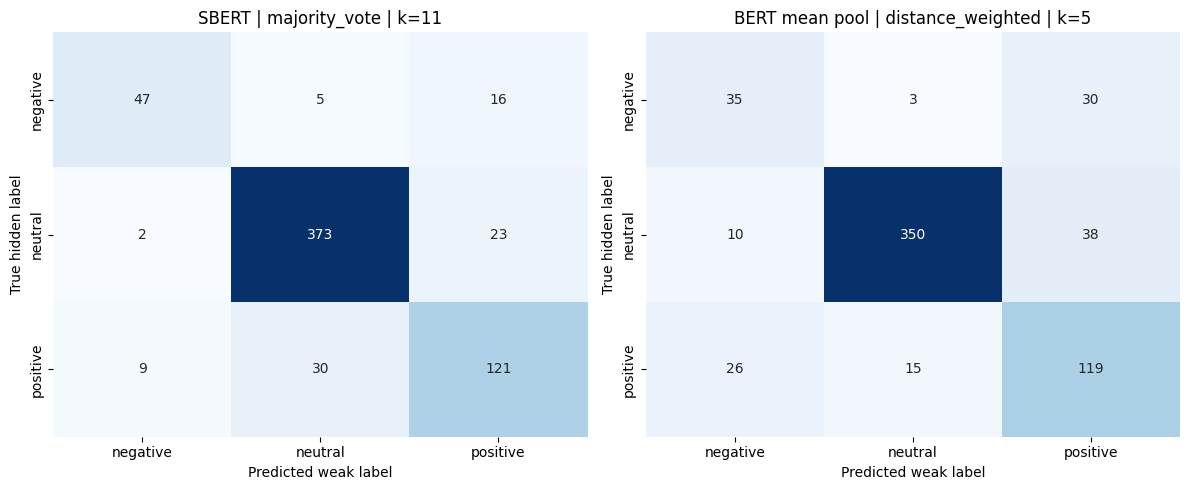

Best weak-label configuration:
{'embedding_name': 'SBERT', 'vote_mode': 'majority_vote', 'k': 11, 'seed_size': 1000, 'accuracy': 0.8642172523961661, 'macro_f1': 0.8092800195622777, 'negative_precision': 0.8103448275862069, 'negative_recall': 0.6911764705882353, 'negative_f1': 0.746031746031746, 'mean_vote_confidence': 0.7888469358117921}
Combined seed + weak-label rows: 1626


In [19]:
ranking_columns = ["negative_f1", "macro_f1", "accuracy", "vote_mode", "k"]
ranking_order = [False, False, False, True, True]

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)
best_overall_row = (
    weak_label_results_df
    .sort_values(ranking_columns, ascending=ranking_order)
    .iloc[0]
)

# Reuse one fixed weak-label setting below so the semi-supervised comparison stays simple.
best_embedding_name = best_overall_row["embedding_name"]
best_vote_mode = best_overall_row["vote_mode"]
best_k = int(best_overall_row["k"])
best_setting_key = f"{best_embedding_name} | {best_vote_mode} | k={best_k}"
best_weak_labels = weak_label_predictions[best_setting_key]["predicted_labels"]
best_weak_label_results = best_overall_row.to_dict()
best_weak_labeled_hidden_df = weak_label_predictions[best_setting_key][
    "weak_labeled_hidden_df"
].copy()

weak_label_seed_for_next_step_df = weak_label_seed_df[["sentence", "label"]].copy()
weak_label_seed_for_next_step_df["true_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label"] = weak_label_seed_for_next_step_df["label"]
weak_label_seed_for_next_step_df["weak_label_confidence"] = 1.0
weak_label_seed_for_next_step_df["embedding_name"] = "hard_label_seed"
weak_label_seed_for_next_step_df["vote_mode"] = "hard_label_seed"
weak_label_seed_for_next_step_df["k"] = np.nan
weak_label_seed_for_next_step_df["is_weak"] = False
weak_label_seed_for_next_step_df["prediction_correct"] = True

best_combined_train_with_weak_labels_df = pd.concat(
    [
        weak_label_seed_for_next_step_df,
        best_weak_labeled_hidden_df[
            [
                "sentence",
                "label",
                "true_label",
                "weak_label",
                "weak_label_confidence",
                "embedding_name",
                "vote_mode",
                "k",
                "is_weak",
                "prediction_correct",
            ]
        ],
    ],
    ignore_index=True,
)

best_settings_df = pd.DataFrame(
    [best_sbert_row.to_dict(), best_bert_row.to_dict(), best_overall_row.to_dict()]
)
best_settings_df.index = ["best_sbert", "best_bert", "best_overall"]
display(best_settings_df)

best_setting_rows = [best_sbert_row, best_bert_row]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, best_row in zip(axes, best_setting_rows):
    setting_key = (
        f"{best_row['embedding_name']} | {best_row['vote_mode']} | k={int(best_row['k'])}"
    )
    confusion = weak_label_confusion_matrices[setting_key]
    label_order = confusion["label_order"]
    label_names = [SENTIMENT_ID2LABEL[label_id] for label_id in label_order]
    confusion_df = pd.DataFrame(
        confusion["matrix"],
        index=label_names,
        columns=label_names,
    )

    sns.heatmap(
        confusion_df,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax,
    )
    ax.set_title(
        f"{best_row['embedding_name']} | {best_row['vote_mode']} | k={int(best_row['k'])}"
    )
    ax.set_xlabel("Predicted weak label")
    ax.set_ylabel("True hidden label")

plt.tight_layout()
plt.show()

print("Best weak-label configuration:")
print(best_weak_label_results)
print(f"Combined seed + weak-label rows: {len(best_combined_train_with_weak_labels_df)}")


## Weak Labeling Interpretation

Use the result table and the selected confusion matrices above to answer four practical questions:
- whether SBERT produces better weak labels than plain BERT mean pooling
- whether distance weighting improves over simple majority vote
- which `k` gives the best trade-off between `negative_f1` and overall stability
- whether the best weak labels look strong enough to justify semi-supervised retraining

The winning setting is stored in `best_embedding_name`, `best_vote_mode`, and `best_k` and reused unchanged in the next sections.


## Weak Labeling Summary

What this section contributes:
- direct weak-label evaluation on `hidden_allagree_pool`
- an embedding comparison between SBERT and plain BERT mean pooling
- a voting comparison between `majority_vote` and `distance_weighted`
- selection of one best weak-labeling configuration for the downstream semi-supervised experiments

Prepared variables for reuse:
- `best_embedding_name`
- `best_vote_mode`
- `best_k`
- `best_weak_labels`
- `best_weak_label_results`
- `best_weak_labeled_hidden_df`
- `best_combined_train_with_weak_labels_df`

The next section keeps that configuration fixed and asks whether adding these weak labels actually improves classifier training.


# Semi-Supervised Retraining

The next step keeps one classifier backbone fixed and compares the hard-label baseline against hard-plus-weak training across all available clean seed sizes. Before that comparison, the notebook runs one small learning-rate sweep on the selected backbone so the later results are not tied only to the default fine-tuning setting.


## Select the Classifier Backbone

We keep using one classifier backbone for the semi-supervised experiments. The selection rule stays simple: choose the backbone with the best `negative_f1` on `val_allagree` at the largest clean train size, then reuse that same backbone for every train-size comparison below.


In [20]:
semisup_backbone_selection_size = max(train_sizes)

semisup_backbone_candidates_df = baseline_results_df[
    (baseline_results_df["evaluation_split"] == "val_allagree")
    & (baseline_results_df["train_size"] == semisup_backbone_selection_size)
].copy()

# Choose one backbone once, then keep it fixed for the later semi-supervised runs.
selected_backbone_row = (
    semisup_backbone_candidates_df
    .sort_values(
        ["negative_f1", "macro_f1", "model_key"],
        ascending=[False, False, True],
    )
    .iloc[0]
)
selected_backbone_key = selected_backbone_row["model_key"]
selected_backbone_name = selected_backbone_row["model_name"]

selected_backbone_df = pd.DataFrame([selected_backbone_row.to_dict()])
display(selected_backbone_df)

print("Selected backbone key:", selected_backbone_key)
print("Selected backbone model:", selected_backbone_name)


,model_key,model_name,train_size,evaluation_split,negative_f1,accuracy,macro_f1,negative_precision,negative_recall
0,modernbert,answerdotai/ModernBERT-base,1000,val_allagree,0.96,0.933702,0.927207,0.923077,1.0


Selected backbone key: modernbert
Selected backbone model: answerdotai/ModernBERT-base


## Small Learning-Rate Tuning Pass

Before the main semi-supervised comparison, the notebook runs one small validation sweep for the selected backbone on `train_1000`. This keeps the tuning simple and visible in the notebook while reducing dependence on a single default learning rate.


The table below shows the small validation sweep used to fix one learning rate for the later semi-supervised runs.

In [21]:
LEARNING_RATE_CANDIDATES = [2e-5, 3e-5, 5e-5]
LEARNING_RATE_TUNING_SIZE = max(train_sizes)
learning_rate_tuning_results = []

lr_tuning_train_df = splits[f"train_{LEARNING_RATE_TUNING_SIZE}"][["sentence", "label"]].copy()

# Small sweep only: just enough to avoid depending on one default learning rate.
for candidate_learning_rate in LEARNING_RATE_CANDIDATES:
    print(
        f"Testing learning_rate={candidate_learning_rate:.0e} "
        f"for {selected_backbone_key} on train_{LEARNING_RATE_TUNING_SIZE}"
    )

    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(lr_tuning_train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=(
                f"models/lr_tuning_{selected_backbone_key}_"
                f"{str(candidate_learning_rate).replace('.', '_')}"
            ),
            batch_size=16,
            epochs=3,
            learning_rate=candidate_learning_rate,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    val_predictions = trainer.predict(val_dataset)
    val_metrics = compute_metrics(
        (val_predictions.predictions, val_predictions.label_ids),
        negative_label=NEGATIVE_LABEL,
    )

    learning_rate_tuning_results.append(
        {
            "backbone_key": selected_backbone_key,
            "backbone_name": selected_backbone_name,
            "train_size": LEARNING_RATE_TUNING_SIZE,
            "learning_rate": candidate_learning_rate,
            **val_metrics,
        }
    )

learning_rate_tuning_df = pd.DataFrame(learning_rate_tuning_results).sort_values(
    ["negative_f1", "macro_f1", "accuracy", "learning_rate"],
    ascending=[False, False, False, True],
).reset_index(drop=True)
selected_learning_rate = float(learning_rate_tuning_df.iloc[0]["learning_rate"])

display(
    learning_rate_tuning_df.style.format(
        {
            "learning_rate": "{:.0e}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
        }
    ).background_gradient(subset=["negative_f1"], cmap="YlGn")
)

print("Selected learning rate:", f"{selected_learning_rate:.0e}")


Testing learning_rate=2e-05 for modernbert on train_1000


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '36.66', 'train_samples_per_second': '81.84', 'train_steps_per_second': '5.156', 'train_loss': '0.2822', 'epoch': '3'}
Testing learning_rate=3e-05 for modernbert on train_1000


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '36.54', 'train_samples_per_second': '82.11', 'train_steps_per_second': '5.173', 'train_loss': '0.2464', 'epoch': '3'}
Testing learning_rate=5e-05 for modernbert on train_1000


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '40.58', 'train_samples_per_second': '73.93', 'train_steps_per_second': '4.658', 'train_loss': '0.238', 'epoch': '3'}


,backbone_key,backbone_name,train_size,learning_rate,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,modernbert,answerdotai/ModernBERT-base,1000,5e-05,0.9613,0.9530,0.9231,1.0000,0.9600
1,modernbert,answerdotai/ModernBERT-base,1000,2e-05,0.9282,0.9225,0.9231,1.0000,0.9600
2,modernbert,answerdotai/ModernBERT-base,1000,3e-05,0.9503,0.9377,0.8889,1.0000,0.9412


Selected learning rate: 5e-05


## Learning-Rate Tuning Interpretation

This is intentionally a very small sweep, not a large search framework. The selected learning rate is reused in the later hard-only and semi-supervised runs for the chosen backbone so the downstream comparison is based on a slightly stronger and more stable fine-tuning setting.


In [22]:
semisup_eval_splits = {
    "val_allagree": val_allagree_df,
    "test_allagree": test_allagree_df,
    "test_disagree": test_disagree_df,
}

if best_embedding_name == "SBERT":
    semisup_seed_embeddings_by_size = sbert_train_embeddings_by_size
    semisup_hidden_embeddings = sbert_hidden_embeddings
elif best_embedding_name == "BERT mean pool":
    semisup_seed_embeddings_by_size = bert_train_embeddings_by_size
    semisup_hidden_embeddings = bert_hidden_embeddings
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")


def train_and_evaluate_semisup_run(
    run_name,
    train_df,
    seed_size,
    output_dir,
    learning_rate=selected_learning_rate,
):
    """Train one run and evaluate it on the fixed validation and test splits."""
    classifier = SentimentClassifier(
        model_name=selected_backbone_name,
        num_labels=len(SENTIMENT_ID2LABEL),
    )
    classifier.set_label_mapping(SENTIMENT_ID2LABEL, SENTIMENT_LABEL2ID)

    train_dataset = prepare_text_dataset(train_df, classifier.tokenizer)
    val_dataset = prepare_text_dataset(val_allagree_df, classifier.tokenizer)
    data_collator = DataCollatorWithPadding(tokenizer=classifier.tokenizer)

    trainer = Trainer(
        model=classifier.model,
        args=create_training_args(
            output_dir=output_dir,
            batch_size=16,
            epochs=3,
            learning_rate=learning_rate,
            seed=42,
        ),
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=data_collator,
        compute_metrics=lambda eval_pred: compute_metrics(
            eval_pred,
            negative_label=NEGATIVE_LABEL,
        ),
    )
    trainer.train()

    run_results = []
    for evaluation_split_name, evaluation_split_df in semisup_eval_splits.items():
        evaluation_dataset = prepare_text_dataset(
            evaluation_split_df,
            classifier.tokenizer,
        )
        evaluation_predictions = trainer.predict(evaluation_dataset)
        evaluation_metrics = compute_metrics(
            (evaluation_predictions.predictions, evaluation_predictions.label_ids),
            negative_label=NEGATIVE_LABEL,
        )

        run_results.append(
            {
                "run_type": run_name,
                "backbone_key": selected_backbone_key,
                "backbone_name": selected_backbone_name,
                "learning_rate": learning_rate,
                "train_size": seed_size,
                "evaluation_split": evaluation_split_name,
                **evaluation_metrics,
            }
        )

    return run_results


In [23]:
semisup_results = []
semisup_results_by_size = {}

for semisup_train_size in train_sizes:
    print()
    print(f"=== Semi-supervised comparison for train_{semisup_train_size} ===")

    current_seed_df = splits[f"train_{semisup_train_size}"][["sentence", "label"]].copy()
    current_seed_labels = train_labels_by_size[semisup_train_size]
    current_seed_embeddings = semisup_seed_embeddings_by_size[semisup_train_size]

    # Regenerate weak labels for each seed size, but keep the hidden pool itself fixed.
    (
        current_weak_labels,
        current_neighbor_indices,
        current_neighbor_distances,
        current_confidence_scores,
    ) = predict_knn_labels(
        train_embeddings=current_seed_embeddings,
        train_labels=current_seed_labels,
        query_embeddings=semisup_hidden_embeddings,
        k=best_k,
        vote_mode=best_vote_mode,
    )

    current_weak_hidden_df = hidden_allagree_pool.copy()
    current_weak_hidden_df["true_label"] = hidden_allagree_pool["label"].to_numpy()
    current_weak_hidden_df["label"] = current_weak_labels
    current_weak_hidden_df["weak_label"] = current_weak_labels
    current_weak_hidden_df["weak_label_confidence"] = current_confidence_scores
    current_weak_hidden_df["embedding_name"] = best_embedding_name
    current_weak_hidden_df["vote_mode"] = best_vote_mode
    current_weak_hidden_df["k"] = best_k
    current_weak_hidden_df["is_weak"] = True

    current_combined_train_df = pd.concat(
        [
            current_seed_df,
            current_weak_hidden_df[["sentence", "label"]],
        ],
        ignore_index=True,
    )

    current_baseline_results = train_and_evaluate_semisup_run(
        run_name="baseline_hard_only",
        train_df=current_seed_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_baseline_{selected_backbone_key}_{semisup_train_size}"
        ),
    )
    current_semisup_results = train_and_evaluate_semisup_run(
        run_name="semi_supervised_hard_plus_weak",
        train_df=current_combined_train_df,
        seed_size=semisup_train_size,
        output_dir=(
            f"models/semisup_curve_weak_{selected_backbone_key}_{semisup_train_size}"
        ),
    )

    semisup_results.extend(current_baseline_results)
    semisup_results.extend(current_semisup_results)
    semisup_results_by_size[semisup_train_size] = {
        "baseline_results": current_baseline_results,
        "semisup_results": current_semisup_results,
        "weak_labels": current_weak_labels,
        "weak_label_confidence": current_confidence_scores,
        "weak_hidden_df": current_weak_hidden_df,
        "combined_train_df": current_combined_train_df,
    }



=== Semi-supervised comparison for train_100 ===


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '4.422', 'train_samples_per_second': '67.84', 'train_steps_per_second': '4.749', 'train_loss': '0.5857', 'epoch': '3'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '35.23', 'train_samples_per_second': '61.83', 'train_steps_per_second': '3.917', 'train_loss': '0.3239', 'epoch': '3'}

=== Semi-supervised comparison for train_250 ===


...

{'train_runtime': '44.84', 'train_samples_per_second': '75.34', 'train_steps_per_second': '4.75', 'train_loss': '0.2576', 'epoch': '3'}

=== Semi-supervised comparison for train_1000 ===


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '38.99', 'train_samples_per_second': '76.95', 'train_steps_per_second': '4.848', 'train_loss': '0.2194', 'epoch': '3'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '65.6', 'train_samples_per_second': '74.36', 'train_steps_per_second': '4.665', 'train_loss': '0.2602', 'epoch': '3'}


The next table compares the hard-label baseline and semi-supervised runs under the same backbone and learning rate.

In [24]:
semisup_learning_curve_df = pd.DataFrame(semisup_results)
semisup_learning_curve_df = semisup_learning_curve_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "learning_rate",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(
    ["evaluation_split", "train_size", "run_type"],
    ascending=[True, True, True],
).reset_index(drop=True)

semisup_comparison_df = semisup_learning_curve_df.copy()
semisup_baseline_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "baseline_hard_only"
].to_dict("records")
semisup_weak_results = semisup_comparison_df[
    semisup_comparison_df["run_type"] == "semi_supervised_hard_plus_weak"
].to_dict("records")

semisup_metric_columns = [
    "accuracy",
    "macro_f1",
    "negative_precision",
    "negative_recall",
    "negative_f1",
]

display(
    semisup_learning_curve_df.style.format(
        {
            "learning_rate": "{:.0e}",
            **{column: "{:.4f}" for column in semisup_metric_columns},
        }
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


,run_type,backbone_key,backbone_name,learning_rate,train_size,evaluation_split,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_allagree,0.7588,0.6535,0.5082,0.5082,0.5082
1,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_allagree,0.7721,0.7169,0.5652,0.8525,0.6797
2,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,250,test_allagree,0.7699,0.6981,0.6071,0.5574,0.5812
3,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,5e-05,250,test_allagree,0.8496,0.8277,0.7662,0.9672,0.8551
4,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,500,test_allagree,0.9270,0.9022,0.9434,0.8197,0.8772
5,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,5e-05,500,test_allagree,0.9049,0.8850,0.8871,0.9016,0.8943
6,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,1000,test_allagree,0.9646,0.9534,0.9355,0.9508,0.9431
7,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,5e-05,1000,test_allagree,0.9447,0.9269,0.9636,0.8689,0.9138
8,baseline_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_disagree,0.5833,0.3762,0.4615,0.1000,0.1644
9,semi_supervised_hard_plus_weak,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_disagree,0.5988,0.5074,0.4902,0.4167,0.4505


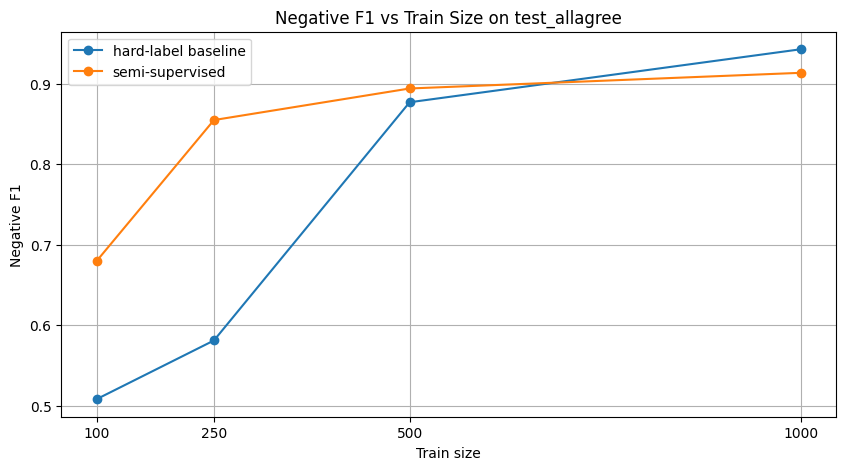

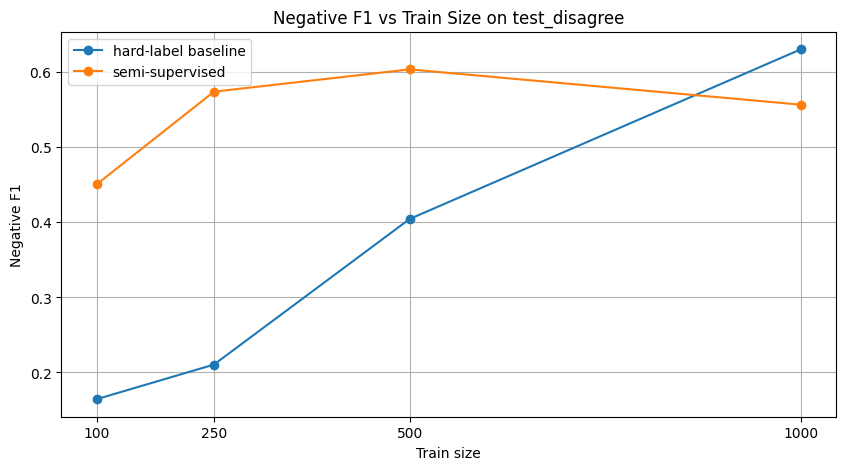

In [25]:
plot_splits = [
    ("test_allagree", "Negative F1 vs Train Size on test_allagree"),
    ("test_disagree", "Negative F1 vs Train Size on test_disagree"),
]
run_label_map = {
    "baseline_hard_only": "hard-label baseline",
    "semi_supervised_hard_plus_weak": "semi-supervised",
}

for evaluation_split_name, plot_title in plot_splits:
    plot_df = semisup_learning_curve_df[
        semisup_learning_curve_df["evaluation_split"] == evaluation_split_name
    ]

    plt.figure(figsize=(10, 5))
    for run_type in ["baseline_hard_only", "semi_supervised_hard_plus_weak"]:
        run_df = plot_df[plot_df["run_type"] == run_type]
        plt.plot(
            run_df["train_size"],
            run_df["negative_f1"],
            marker="o",
            label=run_label_map[run_type],
        )

    plt.title(plot_title)
    plt.xlabel("Train size")
    plt.ylabel("Negative F1")
    plt.xticks(train_sizes)
    plt.legend()
    plt.grid(True)
    plt.show()


## Semi-Supervised Interpretation

The learning curves above compare the hard-label baseline against semi-supervised training with the same tuned backbone, the same selected learning rate, and the same weak-labeling configuration (`best_embedding_name`, `best_vote_mode`, `best_k`).

Focus on three questions:
- does semi-supervised retraining improve `negative_f1`, especially at smaller train sizes
- do any gains carry over to `test_disagree`, not only `test_allagree`
- are the gains large enough to matter for the later time-savings estimate

This section is the direct test of whether the chosen weak-labeling setup helps beyond the supervised baseline.


## Semi-Supervised Summary

What this section contributes:
- a fixed-backbone comparison between the hard-label baseline and hard-plus-weak training
- learning curves across `train_100`, `train_250`, `train_500`, and `train_1000`
- one small learning-rate sweep for the selected backbone before the main semi-supervised runs
- one consistent semi-supervised setup that can be reused for time-savings and agreement analysis

Prepared variables for the next sections:
- `selected_learning_rate`
- `semisup_learning_curve_df`
- `semisup_results_by_size`
- `selected_backbone_name`

The next section translates these learning-curve results into an interpolated manual-label savings estimate.


# Time-Savings Estimate

This section uses the observed learning curves to estimate how many manual labels the semi-supervised setup might save. The main reference metric is `negative_f1` on `test_allagree`.

The estimate works by taking a semi-supervised score and asking where the hard-label baseline would need to be on the same curve to match it.

This addresses the assignment requirement to estimate manual-label savings from weak labeling / semi-supervised learning.

Read this estimate together with the agreement-level seed comparison below, because seed-label quality can affect the practical savings.


In [26]:
time_savings_eval_splits = ["test_allagree", "test_disagree"]

baseline_curve_for_savings_df = semisup_learning_curve_df[
    (semisup_learning_curve_df["run_type"] == "baseline_hard_only")
    & (semisup_learning_curve_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()

semisup_curve_for_savings_df = semisup_learning_curve_df[
    (semisup_learning_curve_df["run_type"] == "semi_supervised_hard_plus_weak")
    & (semisup_learning_curve_df["evaluation_split"].isin(time_savings_eval_splits))
][["train_size", "evaluation_split", "negative_f1"]].copy()


def interpolate_baseline_labels_needed(baseline_split_df, target_negative_f1):
    """Map a semi-supervised score back onto the hard-label baseline curve."""
    baseline_split_df = baseline_split_df.sort_values("train_size").reset_index(drop=True)
    x_values = baseline_split_df["train_size"].to_numpy(dtype=float)
    y_values = baseline_split_df["negative_f1"].to_numpy(dtype=float)

    if target_negative_f1 < y_values.min():
        return np.nan, "below observed baseline range"
    if target_negative_f1 > y_values.max():
        return np.nan, "above observed baseline range"

    exact_matches = baseline_split_df[
        np.isclose(baseline_split_df["negative_f1"], target_negative_f1, atol=1e-10)
    ]
    if not exact_matches.empty:
        return float(exact_matches["train_size"].min()), "exact observed baseline point"

    candidate_estimates = []
    for idx in range(len(baseline_split_df) - 1):
        x1, x2 = x_values[idx], x_values[idx + 1]
        y1, y2 = y_values[idx], y_values[idx + 1]
        lower_y, upper_y = sorted([y1, y2])

        if lower_y <= target_negative_f1 <= upper_y:
            if np.isclose(y1, y2):
                candidate_estimates.append(x1)
            else:
                fraction = (target_negative_f1 - y1) / (y2 - y1)
                candidate_estimates.append(x1 + fraction * (x2 - x1))

    if not candidate_estimates:
        return np.nan, "within range but no crossing segment found"

    return float(min(candidate_estimates)), "linearly interpolated between baseline points"


time_savings_rows = []

for evaluation_split_name in time_savings_eval_splits:
    baseline_split_df = baseline_curve_for_savings_df[
        baseline_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")
    semisup_split_df = semisup_curve_for_savings_df[
        semisup_curve_for_savings_df["evaluation_split"] == evaluation_split_name
    ].sort_values("train_size")

    for _, semisup_row in semisup_split_df.iterrows():
        target_negative_f1 = float(semisup_row["negative_f1"])
        (
            interpolated_baseline_labels_needed,
            interpolation_status,
        ) = interpolate_baseline_labels_needed(
            baseline_split_df,
            target_negative_f1,
        )

        if pd.isna(interpolated_baseline_labels_needed):
            absolute_labels_saved = np.nan
            relative_labels_saved_pct = np.nan
        else:
            absolute_labels_saved = (
                interpolated_baseline_labels_needed
                - float(semisup_row["train_size"])
            )
            relative_labels_saved_pct = (
                100 * absolute_labels_saved / interpolated_baseline_labels_needed
            )

        time_savings_rows.append(
            {
                "eval_split": evaluation_split_name,
                "semi_supervised_train_size": int(semisup_row["train_size"]),
                "semi_supervised_negative_f1": target_negative_f1,
                "interpolated_baseline_labels_needed": interpolated_baseline_labels_needed,
                "absolute_labels_saved": absolute_labels_saved,
                "relative_labels_saved_pct": relative_labels_saved_pct,
                "interpolation_status": interpolation_status,
            }
        )

time_savings_df = pd.DataFrame(time_savings_rows)
primary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_allagree"
].reset_index(drop=True)
secondary_time_savings_df = time_savings_df[
    time_savings_df["eval_split"] == "test_disagree"
].reset_index(drop=True)

display(
    time_savings_df.style.format(
        {
            "semi_supervised_negative_f1": "{:.4f}",
            "interpolated_baseline_labels_needed": "{:.1f}",
            "absolute_labels_saved": "{:.1f}",
            "relative_labels_saved_pct": "{:.1f}",
        },
        na_rep="not estimated",
    ).background_gradient(
        subset=["absolute_labels_saved"],
        cmap="YlGn",
    )
)


,eval_split,semi_supervised_train_size,semi_supervised_negative_f1,interpolated_baseline_labels_needed,absolute_labels_saved,relative_labels_saved_pct,interpolation_status
0,test_allagree,100,0.6797,333.2,233.2,70.0,linearly interpolated between baseline points
1,test_allagree,250,0.8551,481.3,231.3,48.1,linearly interpolated between baseline points
2,test_allagree,500,0.8943,629.9,129.9,20.6,linearly interpolated between baseline points
3,test_allagree,1000,0.9138,777.7,-222.3,-28.6,linearly interpolated between baseline points
4,test_disagree,100,0.4505,601.6,501.6,83.4,linearly interpolated between baseline points
5,test_disagree,250,0.5741,875.0,625.0,71.4,linearly interpolated between baseline points
6,test_disagree,500,0.6038,940.6,440.6,46.8,linearly interpolated between baseline points
7,test_disagree,1000,0.5567,836.5,-163.5,-19.5,linearly interpolated between baseline points


The bar chart below shows the estimated manual labels saved on `test_allagree` after interpolation onto the hard-label baseline curve.

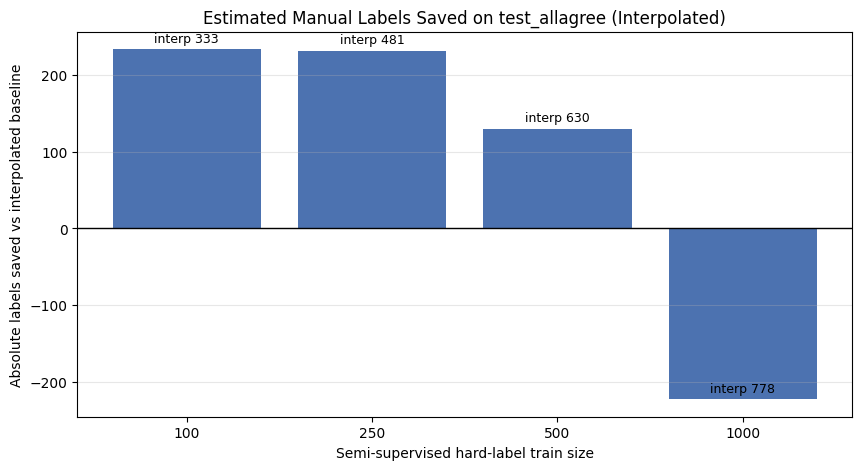

In [27]:
time_savings_plot_df = primary_time_savings_df.copy()

plt.figure(figsize=(10, 5))
bars = plt.bar(
    time_savings_plot_df["semi_supervised_train_size"].astype(str),
    time_savings_plot_df["absolute_labels_saved"].fillna(0),
    color="#4c72b0",
)

for bar, (_, row) in zip(bars, time_savings_plot_df.iterrows()):
    if pd.notna(row["interpolated_baseline_labels_needed"]):
        label_text = f"interp {row['interpolated_baseline_labels_needed']:.0f}"
        y_value = row["absolute_labels_saved"]
    else:
        label_text = "no estimate"
        y_value = 0

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        y_value + 5,
        label_text,
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.axhline(0, color="black", linewidth=1)
plt.title("Estimated Manual Labels Saved on test_allagree (Interpolated)")
plt.xlabel("Semi-supervised hard-label train size")
plt.ylabel("Absolute labels saved vs interpolated baseline")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Time-Savings Interpretation

This estimate is a proxy for manual-label savings: how many hard labels the semi-supervised setup might avoid while still reaching a similar `negative_f1` to the hard-only baseline.

The estimate now uses simple linear interpolation between neighboring hard-only baseline points, which makes it less dependent on exact discrete train-size matches.

It is still intentionally conservative:
- it only interpolates between observed baseline points already run in the notebook
- it does not extrapolate beyond the observed baseline range
- if a semi-supervised score falls outside the baseline curve range, the table reports that explicitly instead of forcing an estimate

Read this as directional evidence about labeling efficiency, not as an exact cost calculation.


## Time-Savings Summary

What this section contributes:
- a simple linear interpolation rule on the hard-only baseline curve
- absolute and relative manual-label savings estimates where interpolation is supported by observed baseline points
- one compact visualization for the primary `test_allagree` view

This estimate becomes more informative when it is read together with the agreement-level comparison below.


# Agreement-Level Comparison

The final main experiment block addresses the assignment question about annotator agreement. It compares high-agreement seeds from the 100% subset against matched-size lower-agreement seeds while keeping the hidden pool, embedding family, vote mode, `k`, classifier backbone, and tuned learning rate fixed.


In [28]:
agreement_high_seed_dfs_by_size = {
    train_size: splits[f"train_{train_size}"][["sentence", "label"]].copy()
    for train_size in train_sizes
}
agreement_lower_seed_dfs_by_size = {}
agreement_seed_overview_rows = []

for train_size in train_sizes:
    # Match the lower-agreement seed size so the comparison isolates label quality.
    lower_seed_df, _ = train_test_split(
        splits["combined_non100_pool"][["sentence", "label"]].copy(),
        train_size=train_size,
        random_state=42 + train_size,
        stratify=splits["combined_non100_pool"]["label"],
    )
    lower_seed_df = lower_seed_df.reset_index(drop=True)
    agreement_lower_seed_dfs_by_size[train_size] = lower_seed_df

    for seed_condition, seed_df in {
        "high_agreement_seed": agreement_high_seed_dfs_by_size[train_size],
        "lower_agreement_seed": lower_seed_df,
    }.items():
        label_counts = seed_df["label"].value_counts().sort_index()
        agreement_seed_overview_rows.append(
            {
                "train_size": train_size,
                "seed_condition": seed_condition,
                **{
                    f"{label_name}_count": int(label_counts.get(label_id, 0))
                    for label_id, label_name in SENTIMENT_ID2LABEL.items()
                },
            }
        )

agreement_hidden_df = hidden_allagree_pool.copy()
agreement_hidden_true_labels = agreement_hidden_df["label"].to_numpy()

# Keep the hidden_allagree_pool fixed here too, so only the seed quality changes.
if best_embedding_name == "SBERT":
    agreement_hidden_embeddings = sbert_hidden_embeddings
    agreement_high_seed_embeddings_by_size = sbert_train_embeddings_by_size
    agreement_lower_seed_embeddings_by_size = {
        train_size: sbert_model.encode(
            agreement_lower_seed_dfs_by_size[train_size]["sentence"].tolist(),
            batch_size=EMBEDDING_BATCH_SIZE,
            show_progress_bar=SHOW_PROGRESS_BARS,
        )
        for train_size in train_sizes
    }
elif best_embedding_name == "BERT mean pool":
    agreement_hidden_embeddings = bert_hidden_embeddings
    agreement_high_seed_embeddings_by_size = bert_train_embeddings_by_size
    agreement_lower_seed_embeddings_by_size = {
        train_size: encode_with_plain_bert(
            agreement_lower_seed_dfs_by_size[train_size]["sentence"].tolist()
        )
        for train_size in train_sizes
    }
else:
    raise ValueError(f"Unsupported best_embedding_name: {best_embedding_name}")

agreement_seed_overview_df = pd.DataFrame(agreement_seed_overview_rows).sort_values(
    ["train_size", "seed_condition"]
).reset_index(drop=True)
display(agreement_seed_overview_df)


,train_size,seed_condition,negative_count,neutral_count,positive_count
0,100,high_agreement_seed,17,60,23
1,100,lower_agreement_seed,12,57,31
2,250,high_agreement_seed,34,142,74
3,250,lower_agreement_seed,29,144,77
4,500,high_agreement_seed,68,296,136
5,500,lower_agreement_seed,58,288,154
6,1000,high_agreement_seed,150,600,250
7,1000,lower_agreement_seed,117,576,307


The next table compares weak-label quality for high-agreement seeds and lower-agreement seeds at each train size.

In [29]:
agreement_weak_label_results = []
agreement_weak_label_outputs = {}

for train_size in train_sizes:
    agreement_seed_conditions = {
        "high_agreement_seed": {
            "seed_df": agreement_high_seed_dfs_by_size[train_size],
            "seed_labels": agreement_high_seed_dfs_by_size[train_size]["label"].to_numpy(),
            "seed_embeddings": agreement_high_seed_embeddings_by_size[train_size],
        },
        "lower_agreement_seed": {
            "seed_df": agreement_lower_seed_dfs_by_size[train_size],
            "seed_labels": agreement_lower_seed_dfs_by_size[train_size]["label"].to_numpy(),
            "seed_embeddings": agreement_lower_seed_embeddings_by_size[train_size],
        },
    }

    # Reuse the same best embedding family, vote mode, and k from the earlier section.
    for seed_condition, seed_values in agreement_seed_conditions.items():
        (
            predicted_labels,
            neighbor_indices,
            neighbor_distances,
            confidence_scores,
        ) = predict_knn_labels(
            train_embeddings=seed_values["seed_embeddings"],
            train_labels=seed_values["seed_labels"],
            query_embeddings=agreement_hidden_embeddings,
            k=best_k,
            vote_mode=best_vote_mode,
        )

        predicted_logits = np.eye(len(SENTIMENT_ID2LABEL))[predicted_labels]
        metrics = compute_metrics(
            (predicted_logits, agreement_hidden_true_labels),
            negative_label=NEGATIVE_LABEL,
        )

        weak_hidden_df = agreement_hidden_df.copy()
        weak_hidden_df["true_label"] = agreement_hidden_true_labels
        weak_hidden_df["label"] = predicted_labels
        weak_hidden_df["weak_label"] = predicted_labels
        weak_hidden_df["weak_label_confidence"] = confidence_scores
        weak_hidden_df["train_size"] = train_size
        weak_hidden_df["seed_condition"] = seed_condition
        weak_hidden_df["embedding_name"] = best_embedding_name
        weak_hidden_df["vote_mode"] = best_vote_mode
        weak_hidden_df["k"] = best_k
        weak_hidden_df["is_weak"] = True

        agreement_weak_label_results.append(
            {
                "train_size": train_size,
                "seed_condition": seed_condition,
                "embedding_name": best_embedding_name,
                "vote_mode": best_vote_mode,
                "k": best_k,
                **metrics,
                "mean_vote_confidence": confidence_scores.mean(),
            }
        )
        agreement_weak_label_outputs[(train_size, seed_condition)] = {
            "predicted_labels": predicted_labels,
            "neighbor_indices": neighbor_indices,
            "neighbor_distances": neighbor_distances,
            "confidence_scores": confidence_scores,
            "weak_hidden_df": weak_hidden_df,
        }

agreement_weak_label_df = pd.DataFrame(agreement_weak_label_results)
agreement_weak_label_df = agreement_weak_label_df[
    [
        "train_size",
        "seed_condition",
        "embedding_name",
        "vote_mode",
        "k",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
        "mean_vote_confidence",
    ]
].sort_values(["train_size", "seed_condition"]).reset_index(drop=True)

display(
    agreement_weak_label_df.style.format(
        {
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
            "mean_vote_confidence": "{:.3f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


,train_size,seed_condition,embedding_name,vote_mode,k,accuracy,macro_f1,negative_precision,negative_recall,negative_f1,mean_vote_confidence
0,100,high_agreement_seed,SBERT,majority_vote,11,0.7636,0.7028,0.5510,0.7941,0.6506,0.673
1,100,lower_agreement_seed,SBERT,majority_vote,11,0.5895,0.4399,0.3704,0.4412,0.4027,0.559
2,250,high_agreement_seed,SBERT,majority_vote,11,0.8003,0.7375,0.5870,0.7941,0.6750,0.705
3,250,lower_agreement_seed,SBERT,majority_vote,11,0.6885,0.4979,0.5294,0.1324,0.2118,0.597
4,500,high_agreement_seed,SBERT,majority_vote,11,0.8371,0.7658,0.6923,0.6618,0.6767,0.765
5,500,lower_agreement_seed,SBERT,majority_vote,11,0.6709,0.5182,0.4490,0.6471,0.5301,0.646
6,1000,high_agreement_seed,SBERT,majority_vote,11,0.8642,0.8093,0.8103,0.6912,0.7460,0.789
7,1000,lower_agreement_seed,SBERT,majority_vote,11,0.7077,0.5973,0.4811,0.7500,0.5862,0.645


The table below shows the downstream comparison after retraining with the same backbone, learning rate, and weak-labeling setup.

In [30]:
agreement_downstream_results = []

for train_size in train_sizes:
    agreement_high_seed_df = agreement_high_seed_dfs_by_size[train_size]
    agreement_lower_seed_df = agreement_lower_seed_dfs_by_size[train_size]

    agreement_high_combined_train_df = pd.concat(
        [
            agreement_high_seed_df,
            agreement_weak_label_outputs[
                (train_size, "high_agreement_seed")
            ]["weak_hidden_df"][["sentence", "label"]],
        ],
        ignore_index=True,
    )
    agreement_lower_combined_train_df = pd.concat(
        [
            agreement_lower_seed_df,
            agreement_weak_label_outputs[
                (train_size, "lower_agreement_seed")
            ]["weak_hidden_df"][["sentence", "label"]],
        ],
        ignore_index=True,
    )

    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="baseline_high_agreement_hard_only",
            train_df=agreement_high_seed_df,
            seed_size=train_size,
            output_dir=(
                f"models/agreement_baseline_high_{selected_backbone_key}_{train_size}"
            ),
        )
    )
    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="semi_supervised_high_agreement_seed",
            train_df=agreement_high_combined_train_df,
            seed_size=train_size,
            output_dir=f"models/agreement_semisup_high_{selected_backbone_key}_{train_size}",
        )
    )
    agreement_downstream_results.extend(
        train_and_evaluate_semisup_run(
            run_name="semi_supervised_lower_agreement_seed",
            train_df=agreement_lower_combined_train_df,
            seed_size=train_size,
            output_dir=f"models/agreement_semisup_lower_{selected_backbone_key}_{train_size}",
        )
    )

agreement_downstream_df = pd.DataFrame(agreement_downstream_results)
agreement_downstream_df = agreement_downstream_df[
    [
        "run_type",
        "backbone_key",
        "backbone_name",
        "learning_rate",
        "train_size",
        "evaluation_split",
        "accuracy",
        "macro_f1",
        "negative_precision",
        "negative_recall",
        "negative_f1",
    ]
].sort_values(["evaluation_split", "train_size", "run_type"]).reset_index(drop=True)

display(
    agreement_downstream_df.style.format(
        {
            "learning_rate": "{:.0e}",
            "accuracy": "{:.4f}",
            "macro_f1": "{:.4f}",
            "negative_precision": "{:.4f}",
            "negative_recall": "{:.4f}",
            "negative_f1": "{:.4f}",
        }
    ).background_gradient(
        subset=["negative_f1"],
        cmap="YlGn",
    )
)


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '3.636', 'train_samples_per_second': '82.5', 'train_steps_per_second': '5.775', 'train_loss': '0.6446', 'epoch': '3'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '29.19', 'train_samples_per_second': '74.62', 'train_steps_per_second': '4.728', 'train_loss': '0.3291', 'epoch': '3'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '61.44', 'train_samples_per_second': '79.4', 'train_steps_per_second': '4.981', 'train_loss': '0.2507', 'epoch': '3'}


Loading weights:   0%|          | 0/136 [00:00<?, ?it/s]

{'train_runtime': '61.03', 'train_samples_per_second': '79.93', 'train_steps_per_second': '5.014', 'train_loss': '0.4442', 'epoch': '3'}


,run_type,backbone_key,backbone_name,learning_rate,train_size,evaluation_split,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_allagree,0.7345,0.6016,0.5000,0.3115,0.3838
1,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_allagree,0.7898,0.7384,0.6118,0.8525,0.7123
2,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,100,test_allagree,0.6460,0.4950,0.3929,0.5410,0.4552
3,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,250,test_allagree,0.7832,0.7053,0.6182,0.5574,0.5862
4,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,250,test_allagree,0.8319,0.8138,0.7595,0.9836,0.8571
5,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,250,test_allagree,0.7058,0.4926,0.5714,0.0656,0.1176
6,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,500,test_allagree,0.9314,0.9138,0.9630,0.8525,0.9043
7,semi_supervised_high_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,500,test_allagree,0.9137,0.8951,0.8769,0.9344,0.9048
8,semi_supervised_lower_agreement_seed,modernbert,answerdotai/ModernBERT-base,5e-05,500,test_allagree,0.7301,0.5820,0.5116,0.7213,0.5986
9,baseline_high_agreement_hard_only,modernbert,answerdotai/ModernBERT-base,5e-05,1000,test_allagree,0.9668,0.9515,0.9206,0.9508,0.9355


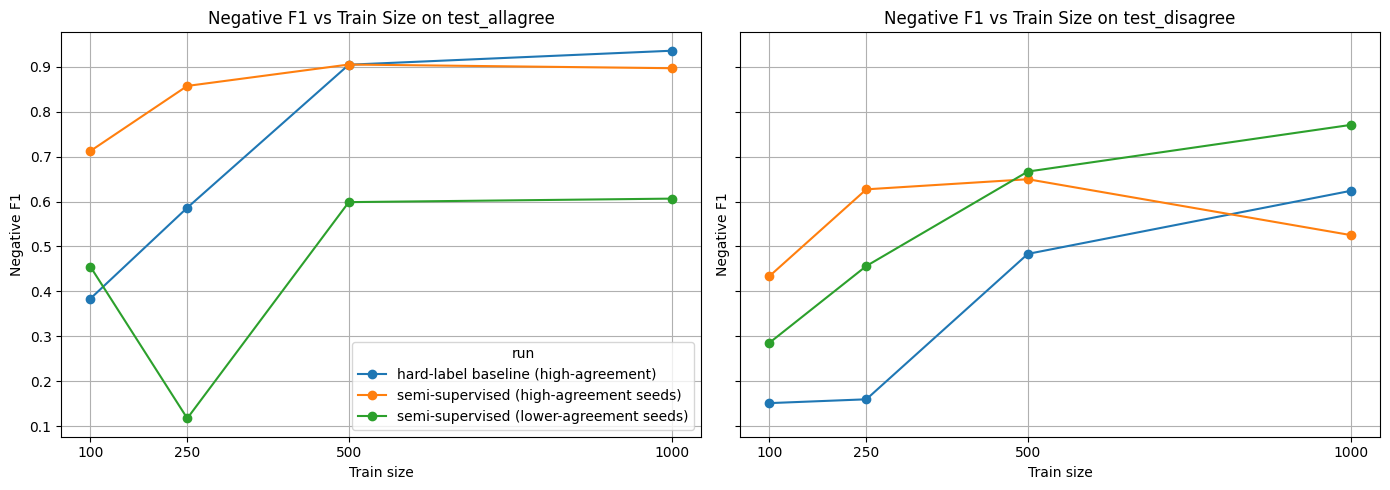

In [31]:
agreement_plot_df = agreement_downstream_df[
    agreement_downstream_df["evaluation_split"].isin(["test_allagree", "test_disagree"])
].copy()
agreement_plot_df["run_label"] = agreement_plot_df["run_type"].map(
    {
        "baseline_high_agreement_hard_only": "hard-label baseline (high-agreement)",
        "semi_supervised_high_agreement_seed": "semi-supervised (high-agreement seeds)",
        "semi_supervised_lower_agreement_seed": "semi-supervised (lower-agreement seeds)",
    }
)
run_order = [
    "hard-label baseline (high-agreement)",
    "semi-supervised (high-agreement seeds)",
    "semi-supervised (lower-agreement seeds)",
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, evaluation_split_name in zip(axes, ["test_allagree", "test_disagree"]):
    split_df = agreement_plot_df[
        agreement_plot_df["evaluation_split"] == evaluation_split_name
    ]

    for run_label in run_order:
        run_df = split_df[split_df["run_label"] == run_label].sort_values("train_size")
        ax.plot(
            run_df["train_size"],
            run_df["negative_f1"],
            marker="o",
            label=run_label,
        )

    ax.set_title(f"Negative F1 vs Train Size on {evaluation_split_name}")
    ax.set_xlabel("Train size")
    ax.set_ylabel("Negative F1")
    ax.set_xticks(train_sizes)
    ax.grid(True)

axes[0].legend(title="run")
plt.tight_layout()
plt.show()


## Agreement-Level Interpretation

This comparison now sweeps across all four train sizes while keeping the rest of the weak-labeling pipeline fixed.

The key question is whether high-agreement seeds lead to:
- better direct weak labels on `hidden_allagree_pool`
- stronger downstream semi-supervised results on `val_allagree`, `test_allagree`, and `test_disagree`
- a larger advantage at smaller train sizes, where seed-label quality should matter most

Because the sweep still fixes one embedding family, one vote mode, one `k`, and one tuned backbone, it should be read as focused evidence about this pipeline rather than as a universal rule.


## Agreement-Level Summary

What this section contributes:
- a matched comparison between high-agreement seeds and lower-agreement seeds across `train_100`, `train_250`, `train_500`, and `train_1000`
- direct weak-label quality results on the same hidden clean pool at every train size
- downstream classifier results with the same selected backbone, vote mode, `k`, and evaluation splits

Together with the earlier learning curves and the interpolated time-savings estimate, this section closes the loop on the assignment's question about how much seed-label quality matters.


# Optional Bonus: LLM In-Context Learning

This appendix is intentionally optional. It only runs if a compatible OpenAI client can be imported and `OPENAI_API_KEY` is available; otherwise it skips itself cleanly and leaves the main notebook flow unchanged.


In [32]:
LLM_BONUS_MODEL = os.getenv("OPENAI_BONUS_MODEL", "gpt-4o-mini")
LLM_BONUS_FEWSHOT_PER_CLASS = 2
LLM_BONUS_EVAL_PER_CLASS = 4
llm_bonus_results_df = pd.DataFrame()
llm_bonus_metrics_df = pd.DataFrame()


def normalize_llm_label(text):
    cleaned = text.strip().splitlines()[0].strip().strip(".: ").lower()
    return SENTIMENT_LABEL2ID.get(cleaned)


def build_llm_fewshot_prompt(fewshot_df, sentence):
    prompt_lines = [
        "You are classifying financial sentiment.",
        "Return exactly one label: negative, neutral, or positive.",
        "",
        "Examples:",
    ]

    for _, row in fewshot_df.iterrows():
        prompt_lines.append(f"Sentence: {row['sentence']}")
        prompt_lines.append(f"Label: {SENTIMENT_ID2LABEL[row['label']]}")
        prompt_lines.append("")

    prompt_lines.append(f"Sentence: {sentence}")
    prompt_lines.append("Label:")
    return "\n".join(prompt_lines)


if not OPENAI_CLIENT_AVAILABLE:
    display(
        Markdown(
            "Optional bonus skipped because the OpenAI client is unavailable in this "
            f"environment: `{type(OPENAI_IMPORT_ERROR).__name__}: {OPENAI_IMPORT_ERROR}`."
        )
    )
elif not os.getenv("OPENAI_API_KEY"):
    display(Markdown("Optional bonus skipped because `OPENAI_API_KEY` is not set."))
else:
    fewshot_df = (
        splits["train_100"]
        .groupby("label", group_keys=False)
        .sample(n=LLM_BONUS_FEWSHOT_PER_CLASS, random_state=42)
        .sort_values("label")
        .reset_index(drop=True)
    )
    llm_eval_df = (
        test_allagree_df
        .groupby("label", group_keys=False)
        .sample(n=LLM_BONUS_EVAL_PER_CLASS, random_state=42)
        .sort_values("label")
        .reset_index(drop=True)
        .copy()
    )

    client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))
    llm_bonus_rows = []

    for _, row in llm_eval_df.iterrows():
        prompt = build_llm_fewshot_prompt(fewshot_df, row["sentence"])
        try:
            response = client.responses.create(
                model=LLM_BONUS_MODEL,
                input=prompt,
            )
            raw_response = response.output_text.strip()
            predicted_label = normalize_llm_label(raw_response)
        except Exception as exc:
            raw_response = f"ERROR: {type(exc).__name__}: {exc}"
            predicted_label = None

        llm_bonus_rows.append(
            {
                "sentence": row["sentence"],
                "true_label": int(row["label"]),
                "true_label_name": SENTIMENT_ID2LABEL[int(row["label"])],
                "raw_response": raw_response,
                "predicted_label": predicted_label,
                "predicted_label_name": (
                    SENTIMENT_ID2LABEL[int(predicted_label)]
                    if predicted_label is not None
                    else None
                ),
            }
        )

    llm_bonus_results_df = pd.DataFrame(llm_bonus_rows)
    display(
        llm_bonus_results_df[
            [
                "sentence",
                "true_label_name",
                "raw_response",
                "predicted_label_name",
            ]
        ]
    )

    valid_llm_bonus_df = llm_bonus_results_df.dropna(subset=["predicted_label"]).copy()
    if valid_llm_bonus_df.empty:
        display(Markdown("The optional LLM bonus ran, but no valid labels were returned."))
    else:
        valid_llm_bonus_df["predicted_label"] = valid_llm_bonus_df["predicted_label"].astype(int)
        llm_bonus_logits = np.eye(len(SENTIMENT_ID2LABEL))[
            valid_llm_bonus_df["predicted_label"]
        ]
        llm_bonus_metrics = compute_metrics(
            (
                llm_bonus_logits,
                valid_llm_bonus_df["true_label"].to_numpy(),
            ),
            negative_label=NEGATIVE_LABEL,
        )
        llm_bonus_metrics_df = pd.DataFrame(
            [
                {
                    "model_name": LLM_BONUS_MODEL,
                    "requested_predictions": len(llm_bonus_results_df),
                    "valid_predictions": len(valid_llm_bonus_df),
                    **llm_bonus_metrics,
                }
            ]
        )
        display(
            llm_bonus_metrics_df.style.format(
                {
                    "accuracy": "{:.4f}",
                    "macro_f1": "{:.4f}",
                    "negative_precision": "{:.4f}",
                    "negative_recall": "{:.4f}",
                    "negative_f1": "{:.4f}",
                }
            )
        )


,sentence,true_label_name,raw_response,predicted_label_name
0,"In September alone , the market declined by 10...",negative,negative,negative
1,The company said that sales in the three month...,negative,negative,negative
2,Finnish electronics contract manufacturer Scan...,negative,negative,negative
3,"In Q1 of 2009 , the company 's operating loss ...",negative,negative,negative
4,"Local government commissioner of +àm+Ñl , Kurt...",neutral,neutral,neutral
5,Mr Jortikka is president of the base metal div...,neutral,neutral,neutral
6,To check them out or to make a bid they will b...,neutral,neutral,neutral
7,"New Chairman of the Board of Directors , Mr Ch...",neutral,neutral,neutral
8,The major breweries increased their domestic b...,positive,positive,positive
9,3 February 2011 - Finnish broadband data commu...,positive,positive,positive


,model_name,requested_predictions,valid_predictions,accuracy,macro_f1,negative_precision,negative_recall,negative_f1
0,gpt-4o-mini,12,12,1.0000,1.0000,1.0000,1.0000,1.0000


# How This Notebook Addresses the Assignment Requirements

This notebook covers the requested components directly and keeps the mapping explicit:
- **Number of manually labeled examples:** the nested seed sets `train_100`, `train_250`, `train_500`, and `train_1000` show how results change with 100, 250, 500, and 1000 manually labeled examples.
- **Annotator agreement level:** agreement is examined both through `test_allagree` versus `test_disagree` and through a matched high-agreement versus lower-agreement sweep across all train sizes.
- **Semi-supervised configuration:** the notebook fixes one selected classifier backbone together with `selected_learning_rate`, `best_embedding_name`, `best_vote_mode`, and `best_k`, then compares hard-only against hard-plus-weak retraining across train sizes.
- **Baseline model comparison:** `baseline_results_df` and the baseline plots compare DistilBERT and ModernBERT under the same data splits and training setup.
- **Embedding comparison:** `embedding_quality_df`, `umap_projection_quality_df`, and `weak_label_results_df` compare SBERT against plain BERT mean pooling for neighborhood quality, 2D structure, and direct weak-label performance.
- **Weak labeling:** the k-NN section generates weak labels for `hidden_allagree_pool`, compares majority voting against distance weighting, evaluates the outputs against the hidden clean labels, and stores the selected setting for reuse.
- **Time-savings estimate:** `time_savings_df` translates the learning curves into an interpolated estimate of possible manual-label savings on the observed baseline curve.
- **Bonus work:** the notebook also includes an optional UMAP visualization and a safe, clearly optional LLM in-context learning appendix.


# Conclusion

The cell below turns the executed result tables into a short, presentation-ready summary of the main findings.


In [33]:
# Turn the stored result tables into one short presentation-friendly summary.
baseline_choice_row = (
    baseline_results_df[
        (baseline_results_df["evaluation_split"] == "val_allagree")
        & (baseline_results_df["train_size"] == max(train_sizes))
    ]
    .sort_values(
        ["negative_f1", "macro_f1", "model_key"],
        ascending=[False, False, True],
    )
    .iloc[0]
)

best_test_baseline_row = (
    baseline_results_df[
        baseline_results_df["evaluation_split"] == "test_allagree"
    ]
    .sort_values(
        ["negative_f1", "macro_f1", "accuracy", "train_size"],
        ascending=[False, False, False, False],
    )
    .iloc[0]
)

best_sbert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "SBERT"]
    .sort_values(
        ["negative_f1", "macro_f1", "accuracy", "vote_mode", "k"],
        ascending=[False, False, False, True, True],
    )
    .iloc[0]
)
best_bert_row = (
    weak_label_results_df[weak_label_results_df["embedding_name"] == "BERT mean pool"]
    .sort_values(
        ["negative_f1", "macro_f1", "accuracy", "vote_mode", "k"],
        ascending=[False, False, False, True, True],
    )
    .iloc[0]
)
best_majority_vote_row = (
    weak_label_results_df[weak_label_results_df["vote_mode"] == "majority_vote"]
    .sort_values(
        ["negative_f1", "macro_f1", "accuracy", "k"],
        ascending=[False, False, False, True],
    )
    .iloc[0]
)
best_distance_weighted_row = (
    weak_label_results_df[weak_label_results_df["vote_mode"] == "distance_weighted"]
    .sort_values(
        ["negative_f1", "macro_f1", "accuracy", "k"],
        ascending=[False, False, False, True],
    )
    .iloc[0]
)

if best_sbert_row["negative_f1"] > best_bert_row["negative_f1"]:
    weak_label_comparison = (
        f"SBERT was stronger for weak labeling than plain BERT mean pooling "
        f"({best_sbert_row['negative_f1']:.3f} vs {best_bert_row['negative_f1']:.3f} "
        "best negative F1)."
    )
elif best_sbert_row["negative_f1"] < best_bert_row["negative_f1"]:
    weak_label_comparison = (
        f"Plain BERT mean pooling was stronger for weak labeling than SBERT "
        f"({best_bert_row['negative_f1']:.3f} vs {best_sbert_row['negative_f1']:.3f} "
        "best negative F1)."
    )
else:
    weak_label_comparison = (
        "SBERT and plain BERT mean pooling tied on best weak-label negative F1 "
        f"({best_sbert_row['negative_f1']:.3f})."
    )

if best_distance_weighted_row["negative_f1"] > best_majority_vote_row["negative_f1"]:
    vote_mode_line = (
        "Distance weighting produced the stronger weak-label result overall "
        f"({best_distance_weighted_row['negative_f1']:.3f} vs "
        f"{best_majority_vote_row['negative_f1']:.3f} best negative F1)."
    )
elif best_distance_weighted_row["negative_f1"] < best_majority_vote_row["negative_f1"]:
    vote_mode_line = (
        "Simple majority vote remained competitive overall "
        f"({best_majority_vote_row['negative_f1']:.3f} vs "
        f"{best_distance_weighted_row['negative_f1']:.3f} best negative F1)."
    )
else:
    vote_mode_line = (
        "Distance weighting and majority vote tied on best negative F1 "
        f"({best_majority_vote_row['negative_f1']:.3f})."
    )

semisup_delta_df = (
    semisup_learning_curve_df
    .pivot_table(
        index=["train_size", "evaluation_split"],
        columns="run_type",
        values="negative_f1",
        aggfunc="first",
    )
    .reset_index()
)
semisup_delta_df["delta_negative_f1"] = (
    semisup_delta_df["semi_supervised_hard_plus_weak"]
    - semisup_delta_df["baseline_hard_only"]
)

allagree_improvements = semisup_delta_df[
    (semisup_delta_df["evaluation_split"] == "test_allagree")
    & (semisup_delta_df["delta_negative_f1"] > 0)
]
disagree_improvements = semisup_delta_df[
    (semisup_delta_df["evaluation_split"] == "test_disagree")
    & (semisup_delta_df["delta_negative_f1"] > 0)
]
best_semisup_gain_row = semisup_delta_df.sort_values(
    "delta_negative_f1",
    ascending=False,
).iloc[0]

if best_semisup_gain_row["delta_negative_f1"] > 0:
    semisup_line = (
        "Semi-supervised retraining improved negative F1 on "
        f"{len(allagree_improvements)}/{len(train_sizes)} observed train sizes for "
        "`test_allagree` and "
        f"{len(disagree_improvements)}/{len(train_sizes)} for `test_disagree`; "
        f"the largest gain was {best_semisup_gain_row['delta_negative_f1']:.3f} on "
        f"{best_semisup_gain_row['evaluation_split']} at train size "
        f"{int(best_semisup_gain_row['train_size'])}."
    )
else:
    semisup_line = (
        "Semi-supervised retraining did not beat the hard-label baseline on the "
        "observed negative_f1 comparisons."
    )

agreement_compare_df = (
    agreement_downstream_df
    .pivot_table(
        index=["train_size", "evaluation_split"],
        columns="run_type",
        values="negative_f1",
        aggfunc="first",
    )
    .reset_index()
)
agreement_compare_df["high_minus_lower"] = (
    agreement_compare_df["semi_supervised_high_agreement_seed"]
    - agreement_compare_df["semi_supervised_lower_agreement_seed"]
)
agreement_better_count = int((agreement_compare_df["high_minus_lower"] > 0).sum())
agreement_total_count = len(agreement_compare_df)
small_train_advantage_count = int(
    (
        agreement_compare_df[
            agreement_compare_df["train_size"].isin([100, 250])
        ]["high_minus_lower"] > 0
    ).sum()
)
small_train_total_count = len(
    agreement_compare_df[agreement_compare_df["train_size"].isin([100, 250])]
)
agreement_line = (
    f"High-agreement seeds were better on {agreement_better_count} of "
    f"{agreement_total_count} train-size and split combinations overall, including "
    f"{small_train_advantage_count} of {small_train_total_count} combinations at "
    "the smaller train sizes (`100` and `250`)."
)

matched_savings_df = primary_time_savings_df.dropna(
    subset=["interpolated_baseline_labels_needed"]
)
if matched_savings_df.empty:
    savings_line = (
        "On the observed `test_allagree` train sizes, the interpolated baseline "
        "curve did not yet produce a supported manual-label savings estimate."
    )
else:
    best_savings_row = matched_savings_df.sort_values(
        ["absolute_labels_saved", "relative_labels_saved_pct"],
        ascending=[False, False],
    ).iloc[0]
    savings_line = (
        "The interpolated time-savings estimate suggests that semi-supervised "
        "training can replace up to "
        f"{best_savings_row['absolute_labels_saved']:.1f} manual labels "
        f"({best_savings_row['relative_labels_saved_pct']:.1f}%) at train size "
        f"{int(best_savings_row['semi_supervised_train_size'])} on `test_allagree`, "
        "when the target score lies within the observed baseline curve range."
    )

final_conclusion_markdown = f"""
- **Best baseline model:** `{baseline_choice_row['model_key']}` was the selected backbone under the notebook's validation rule, and the best `test_allagree` baseline run reached a negative F1 of {best_test_baseline_row['negative_f1']:.3f} at train size {int(best_test_baseline_row['train_size'])}.
- **Best weak-labeling setup:** `{best_embedding_name}` with `{best_vote_mode}` and `k = {best_k}` gave the strongest direct weak-label result on `hidden_allagree_pool`. {weak_label_comparison} {vote_mode_line}
- **Learning-rate tuning:** the small validation sweep selected `selected_learning_rate = {selected_learning_rate:.0e}` for `{selected_backbone_key}` before the later hard-label baseline and semi-supervised runs.
- **Semi-supervised learning:** {semisup_line}
- **Annotator agreement:** {agreement_line}
- **Time-savings estimate:** {savings_line}
- **Limitations:** the time-savings result still depends on the observed baseline curve, the hyperparameter tuning is intentionally narrow, and the optional LLM bonus uses only a tiny subset when credentials are available.
"""

display(Markdown(final_conclusion_markdown))



- **Best baseline model:** `modernbert` was the selected backbone under the notebook's validation rule, and the best `test_allagree` baseline run reached a negative F1 of 0.928 at train size 1000.
- **Best weak-labeling setup:** `SBERT` with `majority_vote` and `k = 11` gave the strongest direct weak-label result on `hidden_allagree_pool`. SBERT was stronger for weak labeling than plain BERT mean pooling (0.746 vs 0.504 best negative F1). Simple majority vote remained competitive overall (0.746 vs 0.736 best negative F1).
- **Learning-rate tuning:** the small validation sweep selected `selected_learning_rate = 5e-05` for `modernbert` before the later hard-label baseline and semi-supervised runs.
- **Semi-supervised learning:** Semi-supervised retraining improved negative F1 on 3/4 observed train sizes for `test_allagree` and 3/4 for `test_disagree`; the largest gain was 0.364 on test_disagree at train size 250.
- **Annotator agreement:** High-agreement seeds were better on 10 of 12 train-size and split combinations overall, including 6 of 6 combinations at the smaller train sizes (`100` and `250`).
- **Time-savings estimate:** The interpolated time-savings estimate suggests that semi-supervised training can replace up to 233.2 manual labels (70.0%) at train size 100 on `test_allagree`, when the target score lies within the observed baseline curve range.
- **Limitations:** the time-savings result still depends on the observed baseline curve, the hyperparameter tuning is intentionally narrow, and the optional LLM bonus uses only a tiny subset when credentials are available.


## Limitations and Future Work

- The time-savings estimate is now smoother because it uses interpolation, but it still depends on the observed baseline curve over the train sizes `100`, `250`, `500`, and `1000`.
- The agreement-level comparison now covers all train sizes, but it still fixes one embedding family, one vote mode, one `k`, and one tuned backbone learning rate.
- The hyperparameter tuning is intentionally small: it only sweeps a few learning rates for one representative train size.
- The optional LLM bonus uses a tiny evaluation subset and may be skipped entirely if no compatible client or API key is available.

The final cell below lists the main result artifacts produced by the notebook and confirms the notebook is ready for review.


In [34]:
final_artifacts_df = pd.DataFrame(
    [
        {
            "variable": "baseline_results_df",
            "description": "Baseline backbone comparison across train sizes and evaluation splits",
        },
        {
            "variable": "umap_projection_quality_df",
            "description": "UMAP-based visual summary for SBERT versus plain BERT on train_1000",
        },
        {
            "variable": "weak_label_results_df",
            "description": "Direct weak-label performance for each embedding family, vote mode, and k",
        },
        {
            "variable": "best_embedding_name, best_vote_mode, best_k",
            "description": "Selected weak-labeling setup reused for semi-supervised training",
        },
        {
            "variable": "selected_learning_rate",
            "description": "Learning rate chosen by the small validation sweep for the selected backbone",
        },
        {
            "variable": "semisup_learning_curve_df",
            "description": "Hard-label baseline versus semi-supervised learning-curve results",
        },
        {
            "variable": "time_savings_df",
            "description": "Interpolated manual-label savings estimate from the learning curves",
        },
        {
            "variable": "agreement_weak_label_df",
            "description": "Direct weak-label comparison for high-agreement versus lower-agreement seeds across all train sizes",
        },
        {
            "variable": "agreement_downstream_df",
            "description": "Downstream agreement-level comparison across all train sizes",
        },
        {
            "variable": "llm_bonus_results_df / llm_bonus_metrics_df",
            "description": "Optional tiny in-context learning bonus outputs when credentials are available",
        },
    ]
)

display(final_artifacts_df)
print("Notebook ready for a full top-to-bottom run and review once the training cells above are executed.")


,variable,description
0,baseline_results_df,Baseline backbone comparison across train size...
1,umap_projection_quality_df,UMAP-based visual summary for SBERT versus pla...
2,weak_label_results_df,Direct weak-label performance for each embeddi...
3,"best_embedding_name, best_vote_mode, best_k",Selected weak-labeling setup reused for semi-s...
4,selected_learning_rate,Learning rate chosen by the small validation s...
5,semisup_learning_curve_df,Hard-label baseline versus semi-supervised lea...
6,time_savings_df,Interpolated manual-label savings estimate fro...
7,agreement_weak_label_df,Direct weak-label comparison for high-agreemen...
8,agreement_downstream_df,Downstream agreement-level comparison across a...
9,llm_bonus_results_df / llm_bonus_metrics_df,Optional tiny in-context learning bonus output...


Notebook ready for a full top-to-bottom run and review once the training cells above are executed.


## Cleanup Note

This final notebook keeps the same workflow and result structure. The last pass only cleaned formatting, added short explanatory remarks, and tightened wording to make the notebook easier to read during submission and grading.